In [4]:
# ============================================
# Cell 1: Install All Dependencies
# ============================================

print("⏳ Installing Dependencies...")

# Core packages
!pip install -q torch torchvision
!pip install -q opencv-python-headless
!pip install -q pandas numpy matplotlib
!pip install -q Pillow
!pip install -q filterpy scipy

print("✅ All Dependencies Installed!")

# Verify installations
import torch
import torchvision
import cv2
import pandas
import numpy
import matplotlib
import PIL
import filterpy

print("\n📊 Version Check:")
print(f"  PyTorch     : {torch.__version__}")
print(f"  Torchvision : {torchvision.__version__}")
print(f"  OpenCV      : {cv2.__version__}")
print(f"  Pandas      : {pandas.__version__}")
print(f"  NumPy       : {numpy.__version__}")
print(f"  Pillow      : {PIL.__version__}")
print(f"\n✅ Cell 1 Complete!")


⏳ Installing Dependencies...
✅ All Dependencies Installed!

📊 Version Check:
  PyTorch     : 2.10.0+cu128
  Torchvision : 0.25.0+cu128
  OpenCV      : 4.13.0
  Pandas      : 2.2.2
  NumPy       : 2.0.2
  Pillow      : 11.3.0

✅ Cell 1 Complete!


In [5]:
# ============================================
# Cell 2: Import All Libraries
# ============================================

import os
import cv2
import time
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torchvision
import torchvision.transforms as T
import torchvision.transforms.functional as TF

from PIL           import Image
from pathlib       import Path
from torch         import nn, optim
from torch.utils.data import Dataset, DataLoader

from torchvision.models.detection            import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.rpn        import AnchorGenerator

from scipy.optimize  import linear_sum_assignment
from filterpy.kalman import KalmanFilter

print("✅ All Libraries Imported!")

# ============================================
# GLOBAL CONFIG
# All settings in one place
# ============================================

# ---- Paths ----
BASE_PATH   = '/content/MOT17/MOT17/train'
SAVE_PATH   = '/content/checkpoints'
os.makedirs(SAVE_PATH, exist_ok=True)

# ---- Sequences ----
SEQUENCES   = [
    'MOT17-02-FRCNN',
    'MOT17-04-FRCNN',
    'MOT17-09-FRCNN'
]
TRAIN_SEQS  = SEQUENCES[:2]
VAL_SEQS    = SEQUENCES[2:]

# ---- Image Settings ----
IMG_HEIGHT    = 600
IMG_WIDTH     = 800
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ---- Training Settings ----
NUM_CLASSES   = 2        # Background + Person
BATCH_SIZE    = 2
NUM_EPOCHS    = 10
LEARNING_RATE = 0.005
MOMENTUM      = 0.9
WEIGHT_DECAY  = 0.0005
NUM_WORKERS   = 2

# ---- Detection Settings ----
CONF_THRESHOLD = 0.5
NMS_THRESHOLD  = 0.4

# ---- Device ----
DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print(f"\n📊 Config Summary:")
print(f"  Device        : {DEVICE}")
print(f"  Image Size    : {IMG_WIDTH}x{IMG_HEIGHT}")
print(f"  Batch Size    : {BATCH_SIZE}")
print(f"  Num Epochs    : {NUM_EPOCHS}")
print(f"  Learning Rate : {LEARNING_RATE}")
print(f"  Train Seqs    : {TRAIN_SEQS}")
print(f"  Val Seqs      : {VAL_SEQS}")
print(f"  Save Path     : {SAVE_PATH}")
print(f"\n✅ Cell 2 Complete!")


✅ All Libraries Imported!

📊 Config Summary:
  Device        : cuda
  Image Size    : 800x600
  Batch Size    : 2
  Num Epochs    : 10
  Learning Rate : 0.005
  Train Seqs    : ['MOT17-02-FRCNN', 'MOT17-04-FRCNN']
  Val Seqs      : ['MOT17-09-FRCNN']
  Save Path     : /content/checkpoints

✅ Cell 2 Complete!


In [6]:
# ============================================
# Cell 3: Download MOT17 Dataset
# ============================================

print("⏳ Downloading MOT17 Dataset...")
print("  This may take a few minutes...")

!wget -q --show-progress \
    https://motchallenge.net/data/MOT17.zip \
    -O /content/MOT17.zip

print("✅ Download Complete!")

# Verify file
size = os.path.getsize('/content/MOT17.zip')
print(f"  File Size: {size / (1024**3):.2f} GB")


⏳ Downloading MOT17 Dataset...
  This may take a few minutes...
/content/MOT17.zip  100%[===================>]   5.46G  8.32MB/s    in 5m 54s  
✅ Download Complete!
  File Size: 5.46 GB


In [7]:
# ============================================
# Cell 3b: Unzip Dataset
# ============================================

print("⏳ Cleaning old files...")
!rm -rf /content/MOT17/
print("✅ Old files removed!")

print("\n⏳ Unzipping Dataset...")
!unzip -q -o /content/MOT17.zip -d /content/MOT17/
print("✅ Unzip Complete!")

# ---- Verify Structure ----
print("\n📂 Dataset Structure:")
for root, dirs, files in os.walk('/content/MOT17'):
    level = root.replace('/content/MOT17', '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}📁 {os.path.basename(root)}/")
    if level < 2:
        for file in files[:3]:
            print(f"{indent}  📄 {file}")

print(f"\n✅ Cell 3b Complete!")


⏳ Cleaning old files...
✅ Old files removed!

⏳ Unzipping Dataset...
✅ Unzip Complete!

📂 Dataset Structure:
📁 MOT17/
  📁 MOT17/
    📁 test/
      📁 MOT17-08-SDP/
        📁 img1/
        📁 det/
      📁 MOT17-06-FRCNN/
        📁 img1/
        📁 det/
      📁 MOT17-03-SDP/
        📁 img1/
        📁 det/
      📁 MOT17-14-DPM/
        📁 img1/
        📁 det/
      📁 MOT17-03-FRCNN/
        📁 img1/
        📁 det/
      📁 MOT17-07-FRCNN/
        📁 img1/
        📁 det/
      📁 MOT17-14-SDP/
        📁 img1/
        📁 det/
      📁 MOT17-14-FRCNN/
        📁 img1/
        📁 det/
      📁 MOT17-01-SDP/
        📁 img1/
        📁 det/
      📁 MOT17-08-DPM/
        📁 img1/
        📁 det/
      📁 MOT17-01-DPM/
        📁 img1/
        📁 det/
      📁 MOT17-07-SDP/
        📁 img1/
        📁 det/
      📁 MOT17-06-DPM/
        📁 img1/
        📁 det/
      📁 MOT17-08-FRCNN/
        📁 img1/
        📁 det/
      📁 MOT17-12-DPM/
        📁 img1/
        📁 det/
      📁 MOT17-12-FRCNN/
        📁 img1/
        📁 det/

In [8]:
# ============================================
# Cell 4: All Helper Functions
# Standalone - No class dependencies
# ============================================

def denormalize(tensor):
    """
    Converts normalized tensor → viewable image
    Input  : tensor (C, H, W) normalized
    Output : tensor (C, H, W) in range [0,1]
    """
    mean   = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std    = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    tensor = tensor.clone().cpu()
    tensor = tensor * std + mean
    tensor = torch.clamp(tensor, 0, 1)
    return tensor


def tensor_to_image(tensor):
    """
    Converts tensor → numpy image for display
    Input  : tensor (C, H, W)
    Output : numpy (H, W, C) uint8
    """
    img = denormalize(tensor)
    img = img.permute(1, 2, 0).numpy()
    img = (img * 255).astype(np.uint8)
    return img.copy()


def fix_boxes(boxes, img_w, img_h):
    """
    Fixes bounding boxes:
    1. Swap if x1>x2 or y1>y2
    2. Clip to image bounds
    3. Remove invalid/tiny boxes

    Input  : numpy (N, 4) x1,y1,x2,y2
    Output : numpy (N, 4) cleaned
    """
    if len(boxes) == 0:
        return boxes

    boxes  = boxes.copy().astype(np.float32)

    # Fix swapped coords
    x1     = np.minimum(boxes[:, 0], boxes[:, 2])
    y1     = np.minimum(boxes[:, 1], boxes[:, 3])
    x2     = np.maximum(boxes[:, 0], boxes[:, 2])
    y2     = np.maximum(boxes[:, 1], boxes[:, 3])

    boxes[:, 0] = x1
    boxes[:, 1] = y1
    boxes[:, 2] = x2
    boxes[:, 3] = y2

    # Clip to image bounds
    boxes[:, 0] = np.clip(boxes[:, 0], 0, img_w)
    boxes[:, 1] = np.clip(boxes[:, 1], 0, img_h)
    boxes[:, 2] = np.clip(boxes[:, 2], 0, img_w)
    boxes[:, 3] = np.clip(boxes[:, 3], 0, img_h)

    # Remove boxes that are too small
    valid  = (
        (boxes[:, 2] - boxes[:, 0] > 1) &
        (boxes[:, 3] - boxes[:, 1] > 1)
    )
    return boxes[valid]


def xywh_to_xyxy(boxes):
    """
    Converts [x, y, w, h] → [x1, y1, x2, y2]
    """
    boxes        = boxes.copy().astype(np.float32)
    boxes[:, 2]  = boxes[:, 0] + boxes[:, 2]
    boxes[:, 3]  = boxes[:, 1] + boxes[:, 3]
    return boxes


def draw_boxes_on_image(image, boxes,
                         color=(0, 255, 0),
                         thickness=2,
                         labels=None):
    """
    Draws bounding boxes on image
    Input  : numpy (H, W, C) uint8
    Output : numpy (H, W, C) uint8 with boxes
    """
    img = image.copy()
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img, (x1,y1), (x2,y2),
                      color, thickness)
        if labels is not None:
            cv2.putText(
                img, str(labels[i]),
                (x1, max(y1-5, 0)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.4, color, 1
            )
    return img


print("✅ Helper Functions Defined!")


# ============================================
# Preprocessing Functions
# ============================================

def preprocess_frame(frame, boxes,
                     augment=False,
                     flip_prob=0.5,
                     brightness=0.3,
                     contrast=0.3,
                     saturation=0.3):
    """
    Complete preprocessing pipeline
    Works for both train and val

    Args:
        frame   : numpy (H, W, C) RGB
        boxes   : numpy (N, 4) x1,y1,x2,y2
        augment : bool - apply augmentation?

    Returns:
        frame_tensor : torch (C, H, W)
        boxes_tensor : torch (N, 4)
    """
    pil_frame      = Image.fromarray(frame)
    orig_w, orig_h = pil_frame.size  # PIL = (W, H)
    boxes          = boxes.copy().astype(np.float32)

    # ---- Augmentation (Train only) ----
    if augment:

        # Random Horizontal Flip
        if random.random() < flip_prob:
            pil_frame   = TF.hflip(pil_frame)
            if len(boxes) > 0:
                old_x1      = boxes[:, 0].copy()
                old_x2      = boxes[:, 2].copy()
                boxes[:, 0] = orig_w - old_x2
                boxes[:, 2] = orig_w - old_x1

        # Fix boxes after flip
        if len(boxes) > 0:
            boxes = fix_boxes(boxes, orig_w, orig_h)

        # Color Jitter
        jitter    = T.ColorJitter(
            brightness = brightness,
            contrast   = contrast,
            saturation = saturation
        )
        pil_frame = jitter(pil_frame)

    # ---- Resize → (H, W) order for TF ----
    pil_frame = TF.resize(
        pil_frame,
        [IMG_HEIGHT, IMG_WIDTH]
    )

    # ---- Scale Boxes ----
    if len(boxes) > 0:
        scale_x     = IMG_WIDTH  / orig_w
        scale_y     = IMG_HEIGHT / orig_h
        boxes[:, 0] *= scale_x
        boxes[:, 1] *= scale_y
        boxes[:, 2] *= scale_x
        boxes[:, 3] *= scale_y
        boxes = fix_boxes(boxes, IMG_WIDTH, IMG_HEIGHT)

    # ---- To Tensor + Normalize ----
    frame_tensor = T.ToTensor()(pil_frame)
    frame_tensor = T.Normalize(
        mean = IMAGENET_MEAN,
        std  = IMAGENET_STD
    )(frame_tensor)

    # ---- Boxes to Tensor ----
    if len(boxes) > 0:
        boxes_tensor = torch.tensor(
            boxes, dtype=torch.float32
        )
    else:
        boxes_tensor = torch.zeros(
            (0, 4), dtype=torch.float32
        )

    return frame_tensor, boxes_tensor


print("✅ Preprocessing Functions Defined!")
print(f"\n✅ Cell 4 Complete!")


✅ Helper Functions Defined!
✅ Preprocessing Functions Defined!

✅ Cell 4 Complete!


In [9]:
# ============================================
# Cell 5 FIXED: Dataset + DataLoader
# Fixes size mismatch in DataLoader
# ============================================

class MOT17Dataset(Dataset):
    def __init__(self, base_path, sequences,
                 is_train=True):
        self.base_path = base_path
        self.sequences = sequences
        self.is_train  = is_train
        self.samples   = []
        self._load_data()

    def _load_data(self):
        for seq in self.sequences:
            img_path = os.path.join(
                self.base_path, seq, 'img1'
            )
            gt_path  = os.path.join(
                self.base_path, seq, 'gt', 'gt.txt'
            )

            gt_df         = pd.read_csv(
                gt_path, header=None
            )
            gt_df.columns = [
                'frame_id', 'obj_id',
                'x', 'y', 'w', 'h',
                'active', 'class', 'visibility'
            ]
            gt_df = gt_df[
                (gt_df['active'] == 1) &
                (gt_df['class']  == 1)
            ]

            frames = sorted([
                f for f in os.listdir(img_path)
                if f.endswith('.jpg')
            ])

            for frame_file in frames:
                frame_id  = int(
                    frame_file.split('.')[0]
                )
                frame_ann = gt_df[
                    gt_df['frame_id'] == frame_id
                ]
                boxes     = frame_ann[
                    ['x', 'y', 'w', 'h']
                ].values

                if len(boxes) > 0:
                    self.samples.append({
                        'frame_path' : os.path.join(
                            img_path, frame_file
                        ),
                        'boxes'      : boxes,
                        'frame_id'   : frame_id,
                        'seq'        : seq
                    })

        print(f"  ✅ Loaded {len(self.samples)} frames")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        # Load frame
        frame  = cv2.imread(sample['frame_path'])
        frame  = cv2.cvtColor(
            frame, cv2.COLOR_BGR2RGB
        )

        # ⚠️ KEY FIX: Force exact size BEFORE anything
        frame  = cv2.resize(
            frame,
            (IMG_WIDTH, IMG_HEIGHT),  # cv2 takes (W, H)
            interpolation = cv2.INTER_LINEAR
        )

        # Verify shape immediately
        assert frame.shape == (IMG_HEIGHT, IMG_WIDTH, 3), \
            f"Frame shape wrong: {frame.shape}"

        # Get original size for box scaling
        orig_h = frame.shape[0]
        orig_w = frame.shape[1]

        # Convert x,y,w,h → x1,y1,x2,y2
        boxes  = sample['boxes'].copy().astype(np.float32)
        boxes[:, 2] = boxes[:, 0] + boxes[:, 2]
        boxes[:, 3] = boxes[:, 1] + boxes[:, 3]

        # Get original image dimensions for scaling
        original_frame = cv2.imread(sample['frame_path'])
        orig_full_h, orig_full_w = original_frame.shape[:2]

        # Scale boxes to resized dimensions
        scale_x     = IMG_WIDTH  / orig_full_w
        scale_y     = IMG_HEIGHT / orig_full_h

        boxes[:, 0] *= scale_x
        boxes[:, 1] *= scale_y
        boxes[:, 2] *= scale_x
        boxes[:, 3] *= scale_y

        # Fix boxes
        boxes = fix_boxes(boxes, IMG_WIDTH, IMG_HEIGHT)

        # Apply augmentation if training
        if self.is_train and random.random() < 0.5:
            # Horizontal flip on numpy array directly
            frame       = np.fliplr(frame).copy()
            if len(boxes) > 0:
                old_x1      = boxes[:, 0].copy()
                old_x2      = boxes[:, 2].copy()
                boxes[:, 0] = IMG_WIDTH - old_x2
                boxes[:, 2] = IMG_WIDTH - old_x1
                boxes       = fix_boxes(
                    boxes, IMG_WIDTH, IMG_HEIGHT
                )

        # Color jitter (train only)
        if self.is_train:
            pil_frame = Image.fromarray(frame)
            jitter    = T.ColorJitter(
                brightness = 0.3,
                contrast   = 0.3,
                saturation = 0.3
            )
            pil_frame = jitter(pil_frame)
            frame     = np.array(pil_frame)

        # ---- Convert to tensor ----
        # frame is now guaranteed (IMG_HEIGHT, IMG_WIDTH, 3)
        frame_tensor = torch.from_numpy(frame)
        frame_tensor = frame_tensor.permute(2, 0, 1)  # HWC → CHW
        frame_tensor = frame_tensor.float() / 255.0

        # Normalize
        mean = torch.tensor(
            IMAGENET_MEAN
        ).view(3, 1, 1)
        std  = torch.tensor(
            IMAGENET_STD
        ).view(3, 1, 1)
        frame_tensor = (frame_tensor - mean) / std

        # Verify tensor shape
        assert frame_tensor.shape == (3, IMG_HEIGHT, IMG_WIDTH), \
            f"Tensor shape wrong: {frame_tensor.shape}"

        # ---- Boxes to tensor ----
        if len(boxes) > 0:
            valid  = (
                (boxes[:, 2] > boxes[:, 0] + 1) &
                (boxes[:, 3] > boxes[:, 1] + 1)
            )
            boxes  = boxes[valid]

        if len(boxes) > 0:
            boxes_tensor = torch.tensor(
                boxes, dtype=torch.float32
            )
        else:
            boxes_tensor = torch.zeros(
                (0, 4), dtype=torch.float32
            )

        target = {
            'boxes'  : boxes_tensor,
            'labels' : torch.ones(
                len(boxes_tensor), dtype=torch.int64
            )
        }

        return frame_tensor, target


# ---- Custom Collate Function ----
def collate_fn(batch):
    """
    Custom collate that handles variable
    number of boxes per frame
    """
    frames  = []
    targets = []

    for frame, target in batch:
        # Double check frame size
        assert frame.shape == (3, IMG_HEIGHT, IMG_WIDTH), \
            f"Wrong frame shape in batch: {frame.shape}"
        frames.append(frame)
        targets.append(target)

    return frames, targets


# ---- Quick Shape Test ----
def test_dataset_shapes(dataset, n=5):
    print("⏳ Testing dataset shapes...")
    original = dataset.is_train
    dataset.is_train = False

    shapes_ok = True
    for i in range(min(n, len(dataset))):
        frame, target = dataset[i]
        expected = (3, IMG_HEIGHT, IMG_WIDTH)
        if frame.shape != expected:
            print(f"  ❌ Sample {i}: "
                  f"Got {frame.shape} "
                  f"Expected {expected}")
            shapes_ok = False
        else:
            print(f"  ✅ Sample {i}: "
                  f"Shape {frame.shape} ✓")

    dataset.is_train = original

    if shapes_ok:
        print(f"\n✅ All shapes correct: "
              f"(3, {IMG_HEIGHT}, {IMG_WIDTH})")
    else:
        print("\n❌ Shape issues found!")

    return shapes_ok


# ---- Create Datasets ----
print("⏳ Creating Datasets...")

train_dataset = MOT17Dataset(
    base_path = BASE_PATH,
    sequences = TRAIN_SEQS,
    is_train  = True
)

val_dataset = MOT17Dataset(
    base_path = BASE_PATH,
    sequences = VAL_SEQS,
    is_train  = False
)

# ---- Test Shapes First! ----
print("\n📊 Shape Verification:")
test_dataset_shapes(train_dataset, n=5)

# ---- Create DataLoaders ----
train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = 2,
    collate_fn  = collate_fn,
    pin_memory  = True if DEVICE.type == 'cuda' else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = 1,
    shuffle     = False,
    num_workers = 2,
    collate_fn  = collate_fn,
    pin_memory  = True if DEVICE.type == 'cuda' else False
)

# ---- Test DataLoader ----
print("\n⏳ Testing DataLoader batch...")
frames, targets = next(iter(train_loader))
print(f"  Batch size     : {len(frames)}")
print(f"  Frame 0 shape  : {frames[0].shape}")
print(f"  Frame 1 shape  : {frames[1].shape}")
print(f"  Target 0 boxes : {targets[0]['boxes'].shape}")

print(f"\n📊 Final Summary:")
print(f"  Train Samples  : {len(train_dataset)}")
print(f"  Val Samples    : {len(val_dataset)}")
print(f"  Train Batches  : {len(train_loader)}")
print(f"  Val Batches    : {len(val_loader)}")
print(f"\n✅ Cell 5 Complete!")


⏳ Creating Datasets...
  ✅ Loaded 1650 frames
  ✅ Loaded 525 frames

📊 Shape Verification:
⏳ Testing dataset shapes...
  ✅ Sample 0: Shape torch.Size([3, 600, 800]) ✓
  ✅ Sample 1: Shape torch.Size([3, 600, 800]) ✓
  ✅ Sample 2: Shape torch.Size([3, 600, 800]) ✓
  ✅ Sample 3: Shape torch.Size([3, 600, 800]) ✓
  ✅ Sample 4: Shape torch.Size([3, 600, 800]) ✓

✅ All shapes correct: (3, 600, 800)

⏳ Testing DataLoader batch...
  Batch size     : 2
  Frame 0 shape  : torch.Size([3, 600, 800])
  Frame 1 shape  : torch.Size([3, 600, 800])
  Target 0 boxes : torch.Size([48, 4])

📊 Final Summary:
  Train Samples  : 1650
  Val Samples    : 525
  Train Batches  : 825
  Val Batches    : 525

✅ Cell 5 Complete!


In [10]:
# ============================================
# Cell 6: Verify Dataset Visually
# ============================================

def verify_dataset(dataset, n_samples=3):
    """
    Shows sample frames with GT boxes
    Augmentation disabled for clean view
    """

    # ---- Disable Augmentation ----
    original         = dataset.is_train
    dataset.is_train = False

    fig, axes = plt.subplots(
        1, n_samples,
        figsize=(18, 6)
    )
    fig.suptitle(
        'Dataset Verification — Ground Truth Boxes',
        fontsize=14, fontweight='bold'
    )

    # Pick spread out samples
    indices = np.linspace(
        0, len(dataset)-1,
        n_samples, dtype=int
    )

    for i, idx in enumerate(indices):
        frame, target = dataset[idx]

        # Convert to displayable image
        img   = tensor_to_image(frame)
        boxes = target['boxes'].numpy()

        print(f"\n  Sample {idx}:")
        print(f"    Frame shape  : {img.shape}")
        print(f"    Num boxes    : {len(boxes)}")
        if len(boxes) > 0:
            print(f"    Box sample   : {boxes[0].astype(int)}")
            print(f"    X range      : "
                  f"[{boxes[:,0].min():.0f}"
                  f" → {boxes[:,2].max():.0f}]"
                  f" (max={IMG_WIDTH})")
            print(f"    Y range      : "
                  f"[{boxes[:,1].min():.0f}"
                  f" → {boxes[:,3].max():.0f}]"
                  f" (max={IMG_HEIGHT})")

        # Draw boxes on image
        img_with_boxes = draw_boxes_on_image(
            img.copy(),
            boxes,
            color     = (0, 255, 0),
            thickness = 2
        )

        axes[i].imshow(img_with_boxes)
        axes[i].set_title(
            f'Sample {idx}\n'
            f'{len(boxes)} Pedestrians\n'
            f'Shape: {img.shape[1]}x{img.shape[0]}',
            fontsize=10,
            color='green'
        )
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

    # ---- Restore Augmentation ----
    dataset.is_train = original


# ============================================
# Run Verification
# ============================================

print("="*45)
print("⏳ Verifying Train Dataset...")
print("="*45)
verify_dataset(train_dataset, n_samples=3)

print("\n")
print("="*45)
print("⏳ Verifying Val Dataset...")
print("="*45)
verify_dataset(val_dataset, n_samples=3)


# ============================================
# Box Statistics Check
# ============================================

def check_box_stats(dataset, n_samples=100):
    """
    Checks box statistics across dataset
    to make sure everything is sane
    """
    print("\n⏳ Checking Box Statistics...")

    original         = dataset.is_train
    dataset.is_train = False

    all_widths  = []
    all_heights = []
    all_counts  = []

    indices = np.linspace(
        0, len(dataset)-1,
        min(n_samples, len(dataset)),
        dtype=int
    )

    for idx in indices:
        _, target = dataset[idx]
        boxes     = target['boxes'].numpy()

        if len(boxes) > 0:
            widths  = boxes[:, 2] - boxes[:, 0]
            heights = boxes[:, 3] - boxes[:, 1]
            all_widths.extend(widths.tolist())
            all_heights.extend(heights.tolist())
            all_counts.append(len(boxes))

    dataset.is_train = original

    if len(all_widths) > 0:
        print(f"\n  📊 Box Statistics ({n_samples} samples):")
        print(f"    Avg box width   : "
              f"{np.mean(all_widths):.1f}px")
        print(f"    Avg box height  : "
              f"{np.mean(all_heights):.1f}px")
        print(f"    Min box width   : "
              f"{np.min(all_widths):.1f}px")
        print(f"    Min box height  : "
              f"{np.min(all_heights):.1f}px")
        print(f"    Max box width   : "
              f"{np.max(all_widths):.1f}px")
        print(f"    Max box height  : "
              f"{np.max(all_heights):.1f}px")
        print(f"    Avg persons/frame: "
              f"{np.mean(all_counts):.1f}")
        print(f"    Max persons/frame: "
              f"{np.max(all_counts)}")

        # ---- Plot Box Size Distribution ----
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        fig.suptitle(
            'Box Size Distribution',
            fontsize=13, fontweight='bold'
        )

        axes[0].hist(
            all_widths, bins=30,
            color='blue', alpha=0.7,
            edgecolor='black'
        )
        axes[0].set_title('Box Widths')
        axes[0].set_xlabel('Width (px)')
        axes[0].set_ylabel('Count')
        axes[0].axvline(
            np.mean(all_widths),
            color='red',
            linestyle='--',
            label=f'Mean: {np.mean(all_widths):.1f}px'
        )
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        axes[1].hist(
            all_heights, bins=30,
            color='green', alpha=0.7,
            edgecolor='black'
        )
        axes[1].set_title('Box Heights')
        axes[1].set_xlabel('Height (px)')
        axes[1].set_ylabel('Count')
        axes[1].axvline(
            np.mean(all_heights),
            color='red',
            linestyle='--',
            label=f'Mean: {np.mean(all_heights):.1f}px'
        )
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # ---- Sanity Checks ----
        print("\n  🔍 Sanity Checks:")
        checks = {
            'All widths > 0'  : all(w > 0 for w in all_widths),
            'All heights > 0' : all(h > 0 for h in all_heights),
            'Max width OK'    : max(all_widths)  <= IMG_WIDTH,
            'Max height OK'   : max(all_heights) <= IMG_HEIGHT,
        }

        all_passed = True
        for check, passed in checks.items():
            status = '✅' if passed else '❌'
            print(f"    {status} {check}")
            if not passed:
                all_passed = False

        if all_passed:
            print(f"\n  ✅ All Sanity Checks Passed!")
        else:
            print(f"\n  ❌ Some Checks Failed!")


# ---- Run Stats Check ----
check_box_stats(train_dataset, n_samples=100)

print(f"\n{'='*45}")
print(f"✅ Cell 6 Complete!")
print(f"{'='*45}")
print(f"\n  Ready for Cell 7 → Build Model! 🚀")


Output hidden; open in https://colab.research.google.com to view.

In [11]:
# ============================================
# Cell 7 FINAL FIX:
# Remove custom AnchorGenerator entirely
# Use DEFAULT anchors that match RPN Head
# ============================================

from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn,
    FasterRCNN_ResNet50_FPN_Weights
)
from torchvision.models.detection.faster_rcnn import (
    FastRCNNPredictor
)

# ============================================
# Step 1: Build Model
# NO custom anchors → No mismatch → No crash!
# ============================================

def build_model(num_classes=2):

    print("⏳ Loading Pretrained Faster R-CNN...")

    try:
        weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
        model   = fasterrcnn_resnet50_fpn(
            weights = weights
        )
        print("  ✅ Loaded with new API!")

    except Exception as e:
        print(f"  ⚠️  New API failed: {e}")
        model = fasterrcnn_resnet50_fpn(
            pretrained = True
        )
        print("  ✅ Loaded with legacy API!")

    # ----------------------------------------
    # NO custom AnchorGenerator!
    # Default anchors already work well
    # for pedestrian detection
    # ----------------------------------------
    print("  ✅ Using DEFAULT anchors (safe!)")

    # ---- Replace Classification Head Only ----
    in_features = (
        model
        .roi_heads
        .box_predictor
        .cls_score
        .in_features
    )
    model.roi_heads.box_predictor = FastRCNNPredictor(
        in_channels = in_features,
        num_classes = num_classes
    )
    print(f"  ✅ Head replaced!")
    print(f"     in_features : {in_features}")
    print(f"     num_classes : {num_classes}")

    return model


# ============================================
# Step 2: Configure Layers
# ============================================

def configure_layers(model, freeze_layers=2):

    print(f"\n⏳ Configuring Layers...")

    backbone_layers = [
        ('layer1', model.backbone.body.layer1),
        ('layer2', model.backbone.body.layer2),
        ('layer3', model.backbone.body.layer3),
        ('layer4', model.backbone.body.layer4),
    ]

    for i, (name, layer) in enumerate(backbone_layers):
        if i < freeze_layers:
            for param in layer.parameters():
                param.requires_grad = False
            print(f"  ❄️  {name} → Frozen")
        else:
            for param in layer.parameters():
                param.requires_grad = True
            print(f"  🔥 {name} → Trainable")

    # Always freeze stem
    for param in model.backbone.body.conv1.parameters():
        param.requires_grad = False
    for param in model.backbone.body.bn1.parameters():
        param.requires_grad = False
    print(f"  ❄️  conv1/bn1 → Frozen")

    # Always train heads
    for param in model.backbone.fpn.parameters():
        param.requires_grad = True
    for param in model.rpn.parameters():
        param.requires_grad = True
    for param in model.roi_heads.parameters():
        param.requires_grad = True

    print(f"  🔥 FPN      → Trainable")
    print(f"  🔥 RPN      → Trainable")
    print(f"  🔥 ROI Head → Trainable")

    return model


# ============================================
# Step 3: Count Parameters
# ============================================

def count_parameters(model):
    trainable = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )
    frozen = sum(
        p.numel()
        for p in model.parameters()
        if not p.requires_grad
    )
    total = trainable + frozen
    return trainable, frozen, total


# ============================================
# Step 4: Verify Model
# ============================================

def verify_model(model, device):
    print("\n⏳ Verifying Model...")

    # ---- Test 1: Eval Mode ----
    print("\n  Test 1: Eval Mode...")
    try:
        model.eval()

        dummy = torch.ones(
            1, 3, IMG_HEIGHT, IMG_WIDTH
        ).to(device) * 0.5

        with torch.no_grad():
            output = model(dummy)

        print(f"  ✅ Eval mode passed!")
        print(f"     Boxes  : {output[0]['boxes'].shape}")
        print(f"     Scores : {output[0]['scores'].shape}")
        print(f"     Labels : {output[0]['labels'].shape}")

    except Exception as e:
        print(f"  ❌ Eval mode FAILED: {e}")
        return False

    # ---- Test 2: Train Mode ----
    print("\n  Test 2: Train Mode...")
    try:
        model.train()

        dummy_frame = torch.ones(
            3, IMG_HEIGHT, IMG_WIDTH
        ).to(device) * 0.5

        dummy_target = [{
            'boxes'  : torch.tensor(
                [[10.0,  10.0,  100.0, 200.0],
                 [150.0, 50.0,  300.0, 400.0]],
                dtype = torch.float32
            ).to(device),
            'labels' : torch.tensor(
                [1, 1],
                dtype = torch.int64
            ).to(device)
        }]

        with torch.no_grad():
            loss_dict = model(
                [dummy_frame],
                dummy_target
            )

        total_loss = sum(
            v.item() for v in loss_dict.values()
        )

        print(f"  ✅ Train mode passed!")
        print(f"     Loss components:")
        for k, v in loss_dict.items():
            print(f"       {k:30s}: {v.item():.4f}")
        print(f"       {'Total':30s}: {total_loss:.4f}")

    except Exception as e:
        print(f"  ❌ Train mode FAILED: {e}")
        return False

    # ---- Test 3: Real Data ----
    print("\n  Test 3: Real Data...")
    try:
        model.eval()

        original               = train_dataset.is_train
        train_dataset.is_train = False

        frame, target = train_dataset[0]

        train_dataset.is_train = original

        frame_input = frame.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(frame_input)

        print(f"  ✅ Real data passed!")
        print(f"     Detections : {len(output[0]['boxes'])}")
        print(f"     GT Boxes   : {len(target['boxes'])}")

    except Exception as e:
        print(f"  ❌ Real data FAILED: {e}")
        return False

    print(f"\n  ✅ ALL Tests Passed!")
    return True


# ============================================
# Step 5: Run Everything
# ============================================

print("=" * 50)
print("🚀 Building Faster R-CNN Model")
print("=" * 50)

# Build
model = build_model(num_classes=NUM_CLASSES)

# Configure
model = configure_layers(model, freeze_layers=2)

# Move to device
model = model.to(DEVICE)
print(f"\n  ✅ Model on : {DEVICE}")

# Count params
trainable, frozen, total = count_parameters(model)

print(f"\n📊 Parameter Summary:")
print(f"  Trainable : {trainable:>12,}")
print(f"  Frozen    : {frozen:>12,}")
print(f"  Total     : {total:>12,}")
print(f"  Trainable : {100*trainable/total:.1f}%")

# Verify
success = verify_model(model, DEVICE)

if success:
    print(f"\n{'='*50}")
    print(f"✅ Cell 7 Complete!")
    print(f"{'='*50}")
    print(f"\n  Ready for Cell 8 → Training! 🚀")
else:
    print(f"\n{'='*50}")
    print(f"❌ Share the error above!")
    print(f"{'='*50}")


🚀 Building Faster R-CNN Model
⏳ Loading Pretrained Faster R-CNN...
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 184MB/s]


  ✅ Loaded with new API!
  ✅ Using DEFAULT anchors (safe!)
  ✅ Head replaced!
     in_features : 1024
     num_classes : 2

⏳ Configuring Layers...
  ❄️  layer1 → Frozen
  ❄️  layer2 → Frozen
  🔥 layer3 → Trainable
  🔥 layer4 → Trainable
  ❄️  conv1/bn1 → Frozen
  🔥 FPN      → Trainable
  🔥 RPN      → Trainable
  🔥 ROI Head → Trainable

  ✅ Model on : cuda

📊 Parameter Summary:
  Trainable :   39,864,345
  Frozen    :    1,434,816
  Total     :   41,299,161
  Trainable : 96.5%

⏳ Verifying Model...

  Test 1: Eval Mode...
  ✅ Eval mode passed!
     Boxes  : torch.Size([100, 4])
     Scores : torch.Size([100])
     Labels : torch.Size([100])

  Test 2: Train Mode...
  ✅ Train mode passed!
     Loss components:
       loss_classifier               : 0.6014
       loss_box_reg                  : 0.1029
       loss_objectness               : 0.6943
       loss_rpn_box_reg              : 0.0341
       Total                         : 1.4326

  Test 3: Real Data...
  ✅ Real data passed!
     

In [12]:
# ============================================
# Cell 8: Training Loop
# ============================================

import time
import os

# ============================================
# Step 1: Target Validator
# Cleans targets before passing to model
# ============================================

def validate_targets(targets, device):
    """
    Ensures all targets are valid:
    - Removes invalid boxes
    - Ensures labels match boxes
    - Handles empty frames safely
    """
    clean = []

    for t in targets:
        boxes  = t['boxes'].to(device)
        labels = t['labels'].to(device)

        # Remove invalid boxes
        if len(boxes) > 0:
            valid  = (
                (boxes[:, 0] >= 0)           &
                (boxes[:, 1] >= 0)           &
                (boxes[:, 2] > boxes[:, 0] + 1) &
                (boxes[:, 3] > boxes[:, 1] + 1) &
                (boxes[:, 2] <= IMG_WIDTH)   &
                (boxes[:, 3] <= IMG_HEIGHT)
            )
            boxes  = boxes[valid]
            labels = labels[valid]

        # If no valid boxes → add dummy box
        # (Faster R-CNN needs at least 1 box)
        if len(boxes) == 0:
            boxes  = torch.tensor(
                [[0.0, 0.0, 10.0, 10.0]],
                dtype = torch.float32
            ).to(device)
            labels = torch.tensor(
                [1],
                dtype = torch.int64
            ).to(device)

        clean.append({
            'boxes'  : boxes,
            'labels' : labels
        })

    return clean


# ============================================
# Step 2: Train One Epoch
# ============================================

def train_one_epoch(model, loader,
                    optimizer, device, epoch):
    """
    Runs one full training epoch

    Returns:
        dict with average losses
    """
    model.train()

    # Loss accumulators
    total_loss      = 0.0
    loss_cls_total  = 0.0
    loss_box_total  = 0.0
    loss_rpn_total  = 0.0
    loss_obj_total  = 0.0

    n_batches       = len(loader)
    skipped         = 0

    for batch_idx, (frames, targets) in enumerate(loader):

        # Move frames to device
        frames  = [f.to(device) for f in frames]

        # Validate + move targets
        targets = validate_targets(targets, device)

        # ---- Forward Pass ----
        try:
            loss_dict = model(frames, targets)
        except Exception as e:
            skipped += 1
            if skipped <= 3:
                print(f"  ⚠️  Batch {batch_idx} "
                      f"skipped: {str(e)[:60]}")
            continue

        # Sum all losses
        losses = sum(
            loss for loss in loss_dict.values()
        )

        # ---- Backward Pass ----
        optimizer.zero_grad()
        losses.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm = 5.0
        )

        optimizer.step()

        # ---- Accumulate Losses ----
        total_loss     += losses.item()
        loss_cls_total += loss_dict.get(
            'loss_classifier',
            torch.tensor(0.0)
        ).item()
        loss_box_total += loss_dict.get(
            'loss_box_reg',
            torch.tensor(0.0)
        ).item()
        loss_rpn_total += loss_dict.get(
            'loss_rpn_box_reg',
            torch.tensor(0.0)
        ).item()
        loss_obj_total += loss_dict.get(
            'loss_objectness',
            torch.tensor(0.0)
        ).item()

        # ---- Progress Print ----
        if (batch_idx + 1) % 50 == 0:
            avg = total_loss / (batch_idx + 1)
            lr  = optimizer.param_groups[0]['lr']
            print(f"    Batch [{batch_idx+1:4d}/{n_batches}]"
                  f"  Loss: {avg:.4f}"
                  f"  LR: {lr:.6f}")

    # ---- Compute Averages ----
    n = max(n_batches - skipped, 1)

    return {
        'total' : total_loss     / n,
        'cls'   : loss_cls_total / n,
        'box'   : loss_box_total / n,
        'rpn'   : loss_rpn_total / n,
        'obj'   : loss_obj_total / n,
    }


# ============================================
# Step 3: Validate One Epoch
# ============================================

def validate_one_epoch(model, loader, device):
    """
    Runs one full validation epoch

    Returns:
        float: average validation loss
    """
    # Faster R-CNN needs train mode for losses
    model.train()

    total_loss = 0.0
    n_batches  = len(loader)
    skipped    = 0

    with torch.no_grad():
        for batch_idx, (frames, targets) in enumerate(loader):

            frames  = [f.to(device) for f in frames]
            targets = validate_targets(targets, device)

            try:
                loss_dict  = model(frames, targets)
                losses     = sum(
                    loss for loss in loss_dict.values()
                )
                total_loss += losses.item()

            except Exception as e:
                skipped += 1
                continue

    n = max(n_batches - skipped, 1)
    return total_loss / n


# ============================================
# Step 4: Setup Optimizer + Scheduler
# ============================================

# Only optimize trainable parameters
params    = [
    p for p in model.parameters()
    if p.requires_grad
]

optimizer = torch.optim.SGD(
    params,
    lr           = LEARNING_RATE,
    momentum     = MOMENTUM,
    weight_decay = WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size = 3,
    gamma     = 0.1
)

print("✅ Optimizer & Scheduler Ready!")
print(f"  Optimizer    : SGD")
print(f"  LR           : {LEARNING_RATE}")
print(f"  Momentum     : {MOMENTUM}")
print(f"  Weight Decay : {WEIGHT_DECAY}")
print(f"  Scheduler    : StepLR (step=3, gamma=0.1)")


# ============================================
# Step 5: Training History
# ============================================

history = {
    'train_loss'     : [],
    'train_cls'      : [],
    'train_box'      : [],
    'train_rpn'      : [],
    'train_obj'      : [],
    'val_loss'       : [],
    'epochs'         : [],
    'learning_rates' : []
}

best_val_loss   = float('inf')
best_model_path = os.path.join(
    SAVE_PATH, 'best_model.pth'
)
last_model_path = os.path.join(
    SAVE_PATH, 'last_model.pth'
)


# ============================================
# Step 6: Main Training Loop
# ============================================

print(f"\n{'='*55}")
print(f"🚀 Starting Training")
print(f"{'='*55}")
print(f"  Epochs        : {NUM_EPOCHS}")
print(f"  Train Batches : {len(train_loader)}")
print(f"  Val Batches   : {len(val_loader)}")
print(f"  Device        : {DEVICE}")
print(f"  Save Path     : {SAVE_PATH}")
print(f"{'='*55}\n")

total_start = time.time()

for epoch in range(1, NUM_EPOCHS + 1):

    epoch_start = time.time()

    print(f"\n{'='*55}")
    print(f"📌 Epoch {epoch}/{NUM_EPOCHS}")
    print(f"{'='*55}")

    # ---- Train ----
    print(f"\n  🔥 Training...")
    train_losses = train_one_epoch(
        model     = model,
        loader    = train_loader,
        optimizer = optimizer,
        device    = DEVICE,
        epoch     = epoch
    )

    # ---- Validate ----
    print(f"\n  🔍 Validating...")
    val_loss = validate_one_epoch(
        model  = model,
        loader = val_loader,
        device = DEVICE
    )

    # ---- Step Scheduler ----
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    # ---- Save History ----
    history['train_loss'].append(train_losses['total'])
    history['train_cls'].append(train_losses['cls'])
    history['train_box'].append(train_losses['box'])
    history['train_rpn'].append(train_losses['rpn'])
    history['train_obj'].append(train_losses['obj'])
    history['val_loss'].append(val_loss)
    history['epochs'].append(epoch)
    history['learning_rates'].append(current_lr)

    # ---- Save Best Model ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch'       : epoch,
            'model_state' : model.state_dict(),
            'optimizer'   : optimizer.state_dict(),
            'val_loss'    : val_loss,
            'history'     : history,
        }, best_model_path)
        best_tag = "  💾 Best model saved!"
    else:
        best_tag = ""

    # ---- Save Last Model ----
    torch.save({
        'epoch'       : epoch,
        'model_state' : model.state_dict(),
        'optimizer'   : optimizer.state_dict(),
        'val_loss'    : val_loss,
        'history'     : history,
    }, last_model_path)

    # ---- Print Epoch Summary ----
    epoch_time = time.time() - epoch_start

    print(f"\n  📊 Epoch {epoch} Summary:")
    print(f"  {'─'*40}")
    print(f"  Train Loss      : {train_losses['total']:.4f}")
    print(f"    ├─ Classifier : {train_losses['cls']:.4f}")
    print(f"    ├─ Box Reg    : {train_losses['box']:.4f}")
    print(f"    ├─ RPN Box    : {train_losses['rpn']:.4f}")
    print(f"    └─ Objectness : {train_losses['obj']:.4f}")
    print(f"  Val Loss        : {val_loss:.4f}")
    print(f"  Best Val Loss   : {best_val_loss:.4f}")
    print(f"  Learning Rate   : {current_lr:.6f}")
    print(f"  Epoch Time      : {epoch_time:.1f}s")
    if best_tag:
        print(best_tag)


# ============================================
# Step 7: Training Complete Summary
# ============================================

total_time = time.time() - total_start

print(f"\n{'='*55}")
print(f"✅ Training Complete!")
print(f"{'='*55}")
print(f"  Total Time    : {total_time/60:.1f} minutes")
print(f"  Best Val Loss : {best_val_loss:.4f}")
print(f"  Best Model    : {best_model_path}")
print(f"  Last Model    : {last_model_path}")
print(f"\n  Loss Progress:")
for i, (t, v) in enumerate(zip(
    history['train_loss'],
    history['val_loss']
)):
    print(f"    Epoch {i+1:2d}: "
          f"Train={t:.4f}  "
          f"Val={v:.4f}")

print(f"\n✅ Cell 8 Complete!")
print(f"  Ready for Cell 9 → Plot Curves! 🚀")


✅ Optimizer & Scheduler Ready!
  Optimizer    : SGD
  LR           : 0.005
  Momentum     : 0.9
  Weight Decay : 0.0005
  Scheduler    : StepLR (step=3, gamma=0.1)

🚀 Starting Training
  Epochs        : 10
  Train Batches : 825
  Val Batches   : 525
  Device        : cuda
  Save Path     : /content/checkpoints


📌 Epoch 1/10

  🔥 Training...
    Batch [  50/825]  Loss: 1.3762  LR: 0.005000
    Batch [ 100/825]  Loss: 1.1620  LR: 0.005000
    Batch [ 150/825]  Loss: 1.0535  LR: 0.005000
    Batch [ 200/825]  Loss: 0.9802  LR: 0.005000
    Batch [ 250/825]  Loss: 0.9343  LR: 0.005000
    Batch [ 300/825]  Loss: 0.8991  LR: 0.005000
    Batch [ 350/825]  Loss: 0.8711  LR: 0.005000
    Batch [ 400/825]  Loss: 0.8405  LR: 0.005000
    Batch [ 450/825]  Loss: 0.8174  LR: 0.005000
    Batch [ 500/825]  Loss: 0.7968  LR: 0.005000
    Batch [ 550/825]  Loss: 0.7772  LR: 0.005000
    Batch [ 600/825]  Loss: 0.7613  LR: 0.005000
    Batch [ 650/825]  Loss: 0.7444  LR: 0.005000
    Batch [ 700/825

⏳ Checking Training History...
  ✅ Found  : train_loss (10 values)
  ✅ Found  : val_loss (10 values)
  ✅ Found  : train_cls (10 values)
  ✅ Found  : train_box (10 values)
  ✅ Found  : train_rpn (10 values)
  ✅ Found  : train_obj (10 values)
  ✅ Found  : epochs (10 values)
  ✅ Found  : learning_rates (10 values)

  📊 Training Summary:
  Total Epochs    : 10
  Best Epoch      : 1
  Best Val Loss   : 0.8207
  Final Train Loss: 0.2738
  Final Val Loss  : 0.9956

📊 Generating Training Plots...

  📈 Plot 1: Main Loss Curve...

  💾 Saved: loss_curve.png


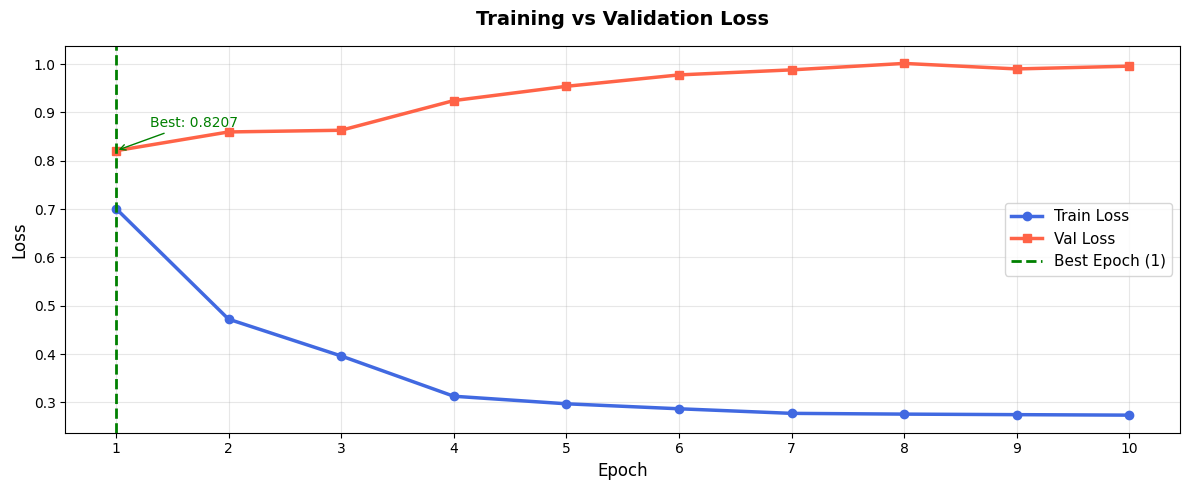

  📈 Plot 2: Component Losses...
  💾 Saved: component_losses.png


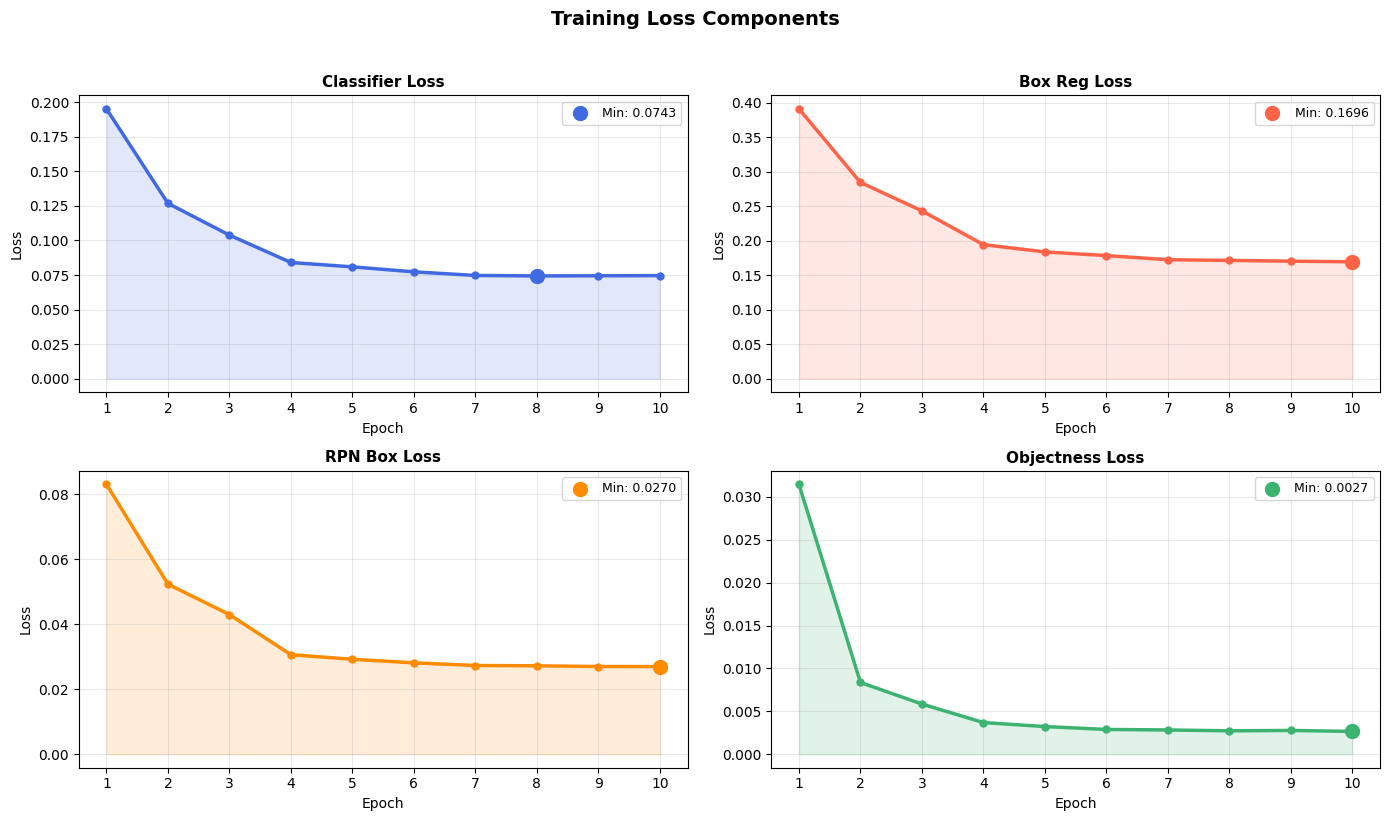

  📈 Plot 3: LR Schedule...
  💾 Saved: lr_schedule.png


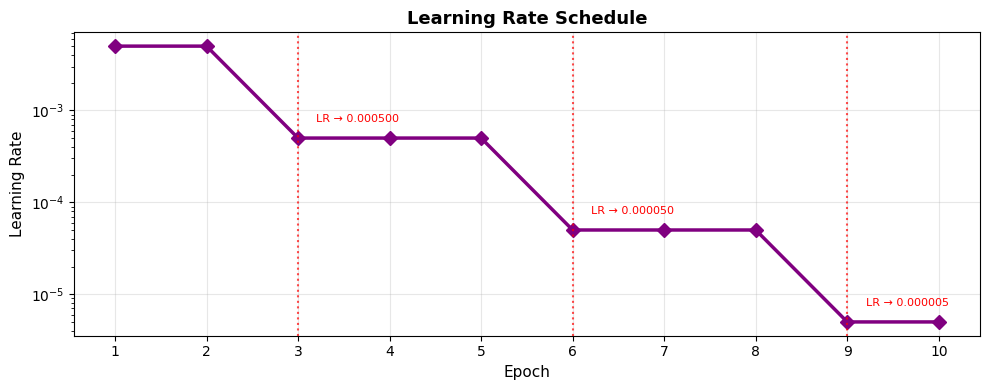

  📈 Plot 4: Full Dashboard...


/tmp/ipykernel_275/4173463574.py:368: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=150,


  💾 Saved: training_dashboard.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


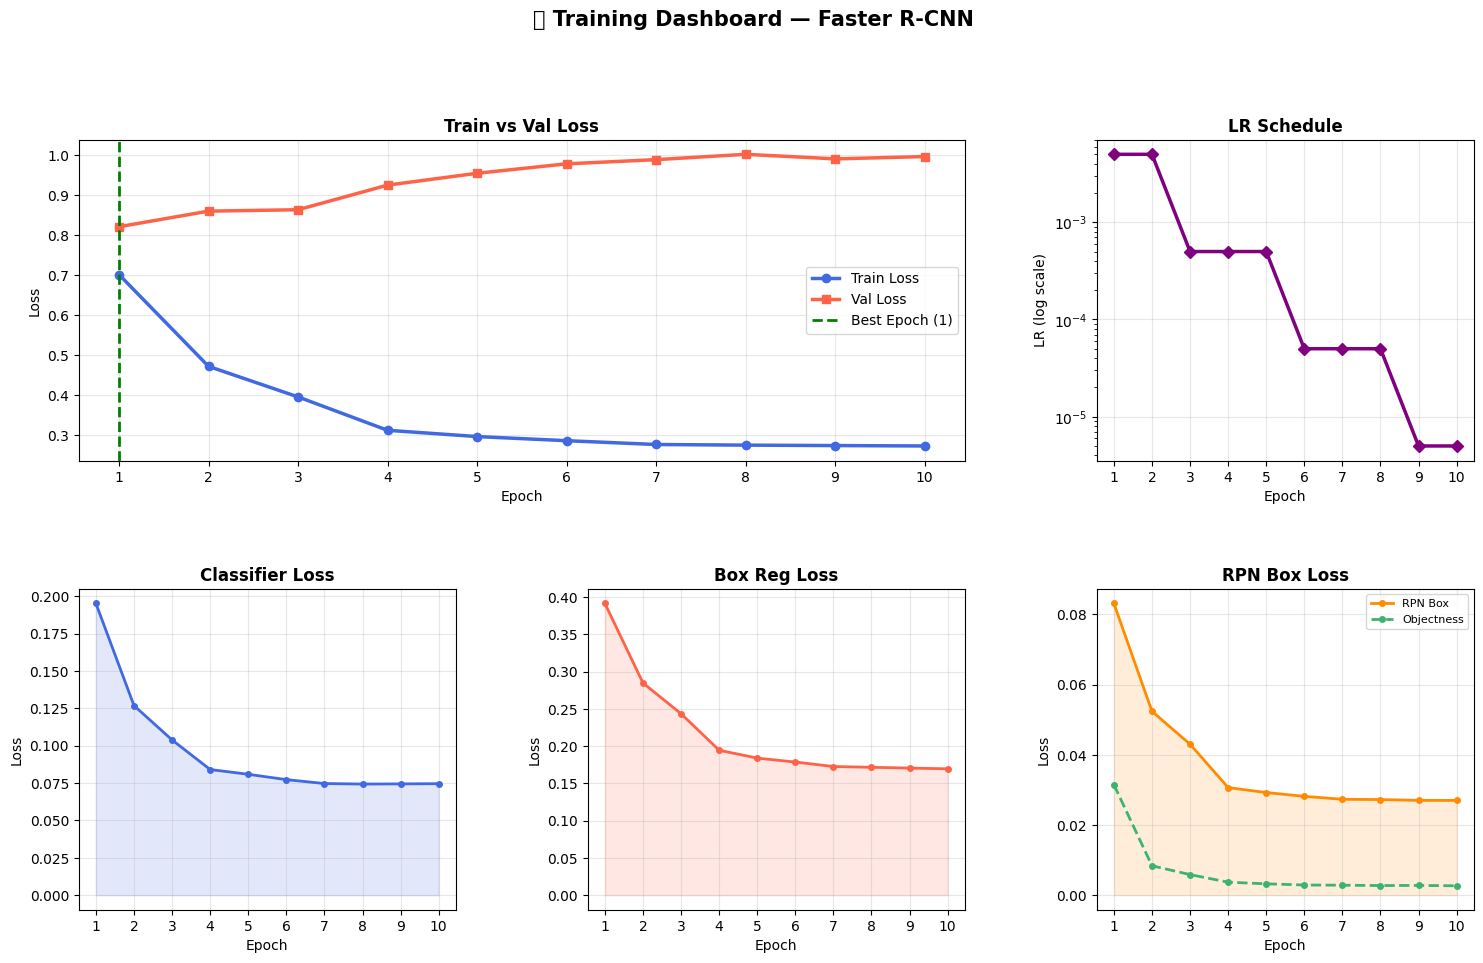


 Epoch |    Train |      Val |      Cls |      Box |         LR
────────────────────────────────────────────────────────────
     1 |   0.7012 |   0.8207 |   0.1952 |   0.3915 |   0.005000 ⭐
     2 |   0.4723 |   0.8596 |   0.1268 |   0.2848 |   0.005000
     3 |   0.3962 |   0.8630 |   0.1038 |   0.2435 |   0.000500
     4 |   0.3129 |   0.9244 |   0.0841 |   0.1945 |   0.000500
     5 |   0.2972 |   0.9540 |   0.0809 |   0.1839 |   0.000500
     6 |   0.2869 |   0.9775 |   0.0773 |   0.1786 |   0.000050
     7 |   0.2774 |   0.9880 |   0.0747 |   0.1726 |   0.000050
     8 |   0.2759 |   1.0013 |   0.0743 |   0.1716 |   0.000050
     9 |   0.2748 |   0.9899 |   0.0744 |   0.1705 |   0.000005
    10 |   0.2738 |   0.9956 |   0.0746 |   0.1696 |   0.000005
────────────────────────────────────────────────────────────
  Best |          |   0.8207 |          |          | Epoch 1 ⭐

✅ Cell 9 Complete!

  Ready for Cell 10 → Evaluate! 🚀


In [13]:
# ============================================
# Cell 9: Plot Training Curves
# ============================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import os

# ============================================
# Step 1: Verify History Exists
# ============================================

print("⏳ Checking Training History...")

required_keys = [
    'train_loss', 'val_loss',
    'train_cls', 'train_box',
    'train_rpn', 'train_obj',
    'epochs', 'learning_rates'
]

for key in required_keys:
    if key not in history:
        print(f"  Missing: {key}")
    else:
        print(f"  Found  : {key} "
              f"({len(history[key])} values)")

epochs       = history['epochs']
train_loss   = history['train_loss']
val_loss     = history['val_loss']
train_cls    = history['train_cls']
train_box    = history['train_box']
train_rpn    = history['train_rpn']
train_obj    = history['train_obj']
lrs          = history['learning_rates']

# Best epoch
best_epoch   = epochs[
    np.argmin(val_loss)
]
best_loss    = min(val_loss)

print(f"\n  📊 Training Summary:")
print(f"  Total Epochs    : {len(epochs)}")
print(f"  Best Epoch      : {best_epoch}")
print(f"  Best Val Loss   : {best_loss:.4f}")
print(f"  Final Train Loss: {train_loss[-1]:.4f}")
print(f"  Final Val Loss  : {val_loss[-1]:.4f}")


# ============================================
# Step 2: Main Loss Plot
# ============================================

def plot_main_losses(epochs, train_loss,
                     val_loss, best_epoch):
    """
    Plots Train vs Val Loss
    """
    fig, ax = plt.subplots(figsize=(12, 5))

    # Plot lines
    ax.plot(
        epochs, train_loss,
        color     = 'royalblue',
        linewidth = 2.5,
        marker    = 'o',
        markersize= 6,
        label     = 'Train Loss'
    )
    ax.plot(
        epochs, val_loss,
        color     = 'tomato',
        linewidth = 2.5,
        marker    = 's',
        markersize= 6,
        label     = 'Val Loss'
    )

    # Best epoch marker
    ax.axvline(
        x         = best_epoch,
        color     = 'green',
        linestyle = '--',
        linewidth = 2.0,
        label     = f'Best Epoch ({best_epoch})'
    )

    # Annotate best val loss
    ax.annotate(
        f'Best: {min(val_loss):.4f}',
        xy        = (best_epoch, min(val_loss)),
        xytext    = (best_epoch + 0.3,
                     min(val_loss) + 0.05),
        fontsize  = 10,
        color     = 'green',
        arrowprops= dict(
            arrowstyle = '->',
            color      = 'green'
        )
    )

    ax.set_title(
        'Training vs Validation Loss',
        fontsize   = 14,
        fontweight = 'bold',
        pad        = 15
    )
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss',  fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(epochs)

    plt.tight_layout()
    save_path = os.path.join(
        SAVE_PATH, 'loss_curve.png'
    )
    plt.savefig(save_path, dpi=150,
                bbox_inches='tight')
    print(f"\n  💾 Saved: loss_curve.png")
    plt.show()


# ============================================
# Step 3: Component Loss Plot
# ============================================

def plot_component_losses(
        epochs, train_cls, train_box,
        train_rpn, train_obj):
    """
    Plots each loss component separately
    """
    fig, axes = plt.subplots(
        2, 2,
        figsize = (14, 8)
    )
    fig.suptitle(
        'Training Loss Components',
        fontsize   = 14,
        fontweight = 'bold',
        y          = 1.02
    )

    components = [
        (train_cls, 'Classifier Loss',
         'royalblue',  axes[0][0]),
        (train_box, 'Box Reg Loss',
         'tomato',     axes[0][1]),
        (train_rpn, 'RPN Box Loss',
         'darkorange',  axes[1][0]),
        (train_obj, 'Objectness Loss',
         'mediumseagreen', axes[1][1]),
    ]

    for values, title, color, ax in components:

        ax.plot(
            epochs, values,
            color     = color,
            linewidth = 2.5,
            marker    = 'o',
            markersize= 5
        )

        # Fill under curve
        ax.fill_between(
            epochs, values,
            alpha = 0.15,
            color = color
        )

        # Min marker
        min_val   = min(values)
        min_epoch = epochs[np.argmin(values)]
        ax.scatter(
            [min_epoch], [min_val],
            color  = color,
            s      = 100,
            zorder = 5,
            label  = f'Min: {min_val:.4f}'
        )

        ax.set_title(title,   fontsize=11,
                     fontweight='bold')
        ax.set_xlabel('Epoch', fontsize=10)
        ax.set_ylabel('Loss',  fontsize=10)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_xticks(epochs)

    plt.tight_layout()
    save_path = os.path.join(
        SAVE_PATH, 'component_losses.png'
    )
    plt.savefig(save_path, dpi=150,
                bbox_inches='tight')
    print(f"  💾 Saved: component_losses.png")
    plt.show()


# ============================================
# Step 4: Learning Rate Plot
# ============================================

def plot_learning_rate(epochs, lrs):
    """
    Plots LR schedule across epochs
    """
    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(
        epochs, lrs,
        color     = 'purple',
        linewidth = 2.5,
        marker    = 'D',
        markersize= 7
    )

    # Annotate LR drops
    for i in range(1, len(lrs)):
        if lrs[i] < lrs[i-1]:
            ax.axvline(
                x         = epochs[i],
                color     = 'red',
                linestyle = ':',
                linewidth = 1.5,
                alpha     = 0.7
            )
            ax.annotate(
                f'LR → {lrs[i]:.6f}',
                xy     = (epochs[i], lrs[i]),
                xytext = (epochs[i] + 0.2,
                          lrs[i] * 1.5),
                fontsize = 8,
                color    = 'red'
            )

    ax.set_title(
        'Learning Rate Schedule',
        fontsize   = 13,
        fontweight = 'bold'
    )
    ax.set_xlabel('Epoch',         fontsize=11)
    ax.set_ylabel('Learning Rate', fontsize=11)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(epochs)

    plt.tight_layout()
    save_path = os.path.join(
        SAVE_PATH, 'lr_schedule.png'
    )
    plt.savefig(save_path, dpi=150,
                bbox_inches='tight')
    print(f"  💾 Saved: lr_schedule.png")
    plt.show()


# ============================================
# Step 5: Combined Dashboard
# ============================================

def plot_dashboard(
        epochs, train_loss, val_loss,
        train_cls, train_box,
        train_rpn, train_obj, lrs):
    """
    Single combined dashboard of all plots
    """
    fig = plt.figure(figsize=(18, 10))
    gs  = gridspec.GridSpec(
        2, 3, figure=fig,
        hspace=0.4, wspace=0.35
    )

    # ---- Main Loss (wide) ----
    ax0 = fig.add_subplot(gs[0, :2])
    ax0.plot(epochs, train_loss,
             color='royalblue', lw=2.5,
             marker='o', ms=6,
             label='Train Loss')
    ax0.plot(epochs, val_loss,
             color='tomato', lw=2.5,
             marker='s', ms=6,
             label='Val Loss')
    ax0.axvline(
        epochs[np.argmin(val_loss)],
        color='green', ls='--', lw=2,
        label=f'Best Epoch '
              f'({epochs[np.argmin(val_loss)]})'
    )
    ax0.set_title('Train vs Val Loss',
                  fontweight='bold')
    ax0.set_xlabel('Epoch')
    ax0.set_ylabel('Loss')
    ax0.legend()
    ax0.grid(True, alpha=0.3)
    ax0.set_xticks(epochs)

    # ---- LR Schedule ----
    ax1 = fig.add_subplot(gs[0, 2])
    ax1.plot(epochs, lrs,
             color='purple', lw=2.5,
             marker='D', ms=6)
    ax1.set_title('LR Schedule',
                  fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('LR (log scale)')
    ax1.set_yscale('log')
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(epochs)

    # ---- Components ----
    components = [
        (train_cls, 'Classifier',  'royalblue'),
        (train_box, 'Box Reg',     'tomato'),
        (train_rpn, 'RPN Box',     'darkorange'),
        (train_obj, 'Objectness',  'mediumseagreen'),
    ]

    positions = [
        gs[1, 0], gs[1, 1],
        gs[1, 2], gs[1, 2]
    ]

    ax2 = fig.add_subplot(gs[1, 0])
    ax3 = fig.add_subplot(gs[1, 1])
    ax4 = fig.add_subplot(gs[1, 2])

    comp_axes = [ax2, ax3, ax4, ax4]

    for j, (vals, title, color) in \
            enumerate(components[:3]):
        ax = comp_axes[j]
        ax.plot(epochs, vals,
                color=color, lw=2.0,
                marker='o', ms=4,
                label=title)
        ax.fill_between(epochs, vals,
                        alpha=0.15, color=color)
        ax.set_title(f'{title} Loss',
                     fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.grid(True, alpha=0.3)
        ax.set_xticks(epochs)

    # Objectness on ax4 with box reg
    ax4.plot(epochs, train_obj,
             color='mediumseagreen',
             lw=2.0, marker='o', ms=4,
             label='Objectness',
             linestyle='--')
    ax4.legend(fontsize=8)

    fig.suptitle(
        '🚀 Training Dashboard — Faster R-CNN',
        fontsize=15, fontweight='bold', y=1.01
    )

    save_path = os.path.join(
        SAVE_PATH, 'training_dashboard.png'
    )
    plt.savefig(save_path, dpi=150,
                bbox_inches='tight')
    print(f"  💾 Saved: training_dashboard.png")
    plt.show()


# ============================================
# Step 6: Run All Plots
# ============================================

print(f"\n{'='*50}")
print(f"📊 Generating Training Plots...")
print(f"{'='*50}\n")

# Plot 1: Main Loss
print("  📈 Plot 1: Main Loss Curve...")
plot_main_losses(
    epochs, train_loss,
    val_loss, best_epoch
)

# Plot 2: Components
print("  📈 Plot 2: Component Losses...")
plot_component_losses(
    epochs, train_cls, train_box,
    train_rpn, train_obj
)

# Plot 3: LR Schedule
print("  📈 Plot 3: LR Schedule...")
plot_learning_rate(epochs, lrs)

# Plot 4: Dashboard
print("  📈 Plot 4: Full Dashboard...")
plot_dashboard(
    epochs, train_loss, val_loss,
    train_cls, train_box,
    train_rpn, train_obj, lrs
)

# ============================================
# Step 7: Print Final Stats Table
# ============================================

print(f"\n{'='*60}")
print(f"{'Epoch':>6} | "
      f"{'Train':>8} | "
      f"{'Val':>8} | "
      f"{'Cls':>8} | "
      f"{'Box':>8} | "
      f"{'LR':>10}")
print(f"{'─'*60}")

for i in range(len(epochs)):
    marker = " ⭐" if epochs[i] == best_epoch \
             else ""
    print(
        f"{epochs[i]:>6} | "
        f"{train_loss[i]:>8.4f} | "
        f"{val_loss[i]:>8.4f} | "
        f"{train_cls[i]:>8.4f} | "
        f"{train_box[i]:>8.4f} | "
        f"{lrs[i]:>10.6f}"
        f"{marker}"
    )

print(f"{'─'*60}")
print(f"{'Best':>6} | "
      f"{'':>8} | "
      f"{best_loss:>8.4f} | "
      f"{'':>8} | "
      f"{'':>8} | "
      f"Epoch {best_epoch} ⭐")

print(f"\n{'='*50}")
print(f"✅ Cell 9 Complete!")
print(f"{'='*50}")
print(f"\n  Ready for Cell 10 → Evaluate! 🚀")


🚀 Cell 10: Evaluate & Visualize
⏳ Loading Best Model...
  ✅ Loaded best model!
     Epoch    : 1
     Val Loss : 0.8207
⏳ Running Inference on Val Set...
  Processed 20/525 batches...
  Processed 40/525 batches...
  Processed 60/525 batches...
  Processed 80/525 batches...
  Processed 100/525 batches...
  Processed 120/525 batches...
  Processed 140/525 batches...
  Processed 160/525 batches...
  Processed 180/525 batches...
  Processed 200/525 batches...
  Processed 220/525 batches...
  Processed 240/525 batches...
  Processed 260/525 batches...
  Processed 280/525 batches...
  Processed 300/525 batches...
  Processed 320/525 batches...
  Processed 340/525 batches...
  Processed 360/525 batches...
  Processed 380/525 batches...
  Processed 400/525 batches...
  Processed 420/525 batches...
  Processed 440/525 batches...
  Processed 460/525 batches...
  Processed 480/525 batches...
  Processed 500/525 batches...
  Processed 520/525 batches...
  ✅ Inference complete!
     Total samples :

/tmp/ipykernel_275/3872352507.py:170: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ap = np.trapz(precisions, recalls)



📊 Evaluation Results @ IoU=0.5
  Precision : 0.5706
  Recall    : 0.7380
  F1 Score  : 0.6436
  mAP@0.5   : 0.6884

⏳ Visualizing Detections...

  💾 Saved: detections.png


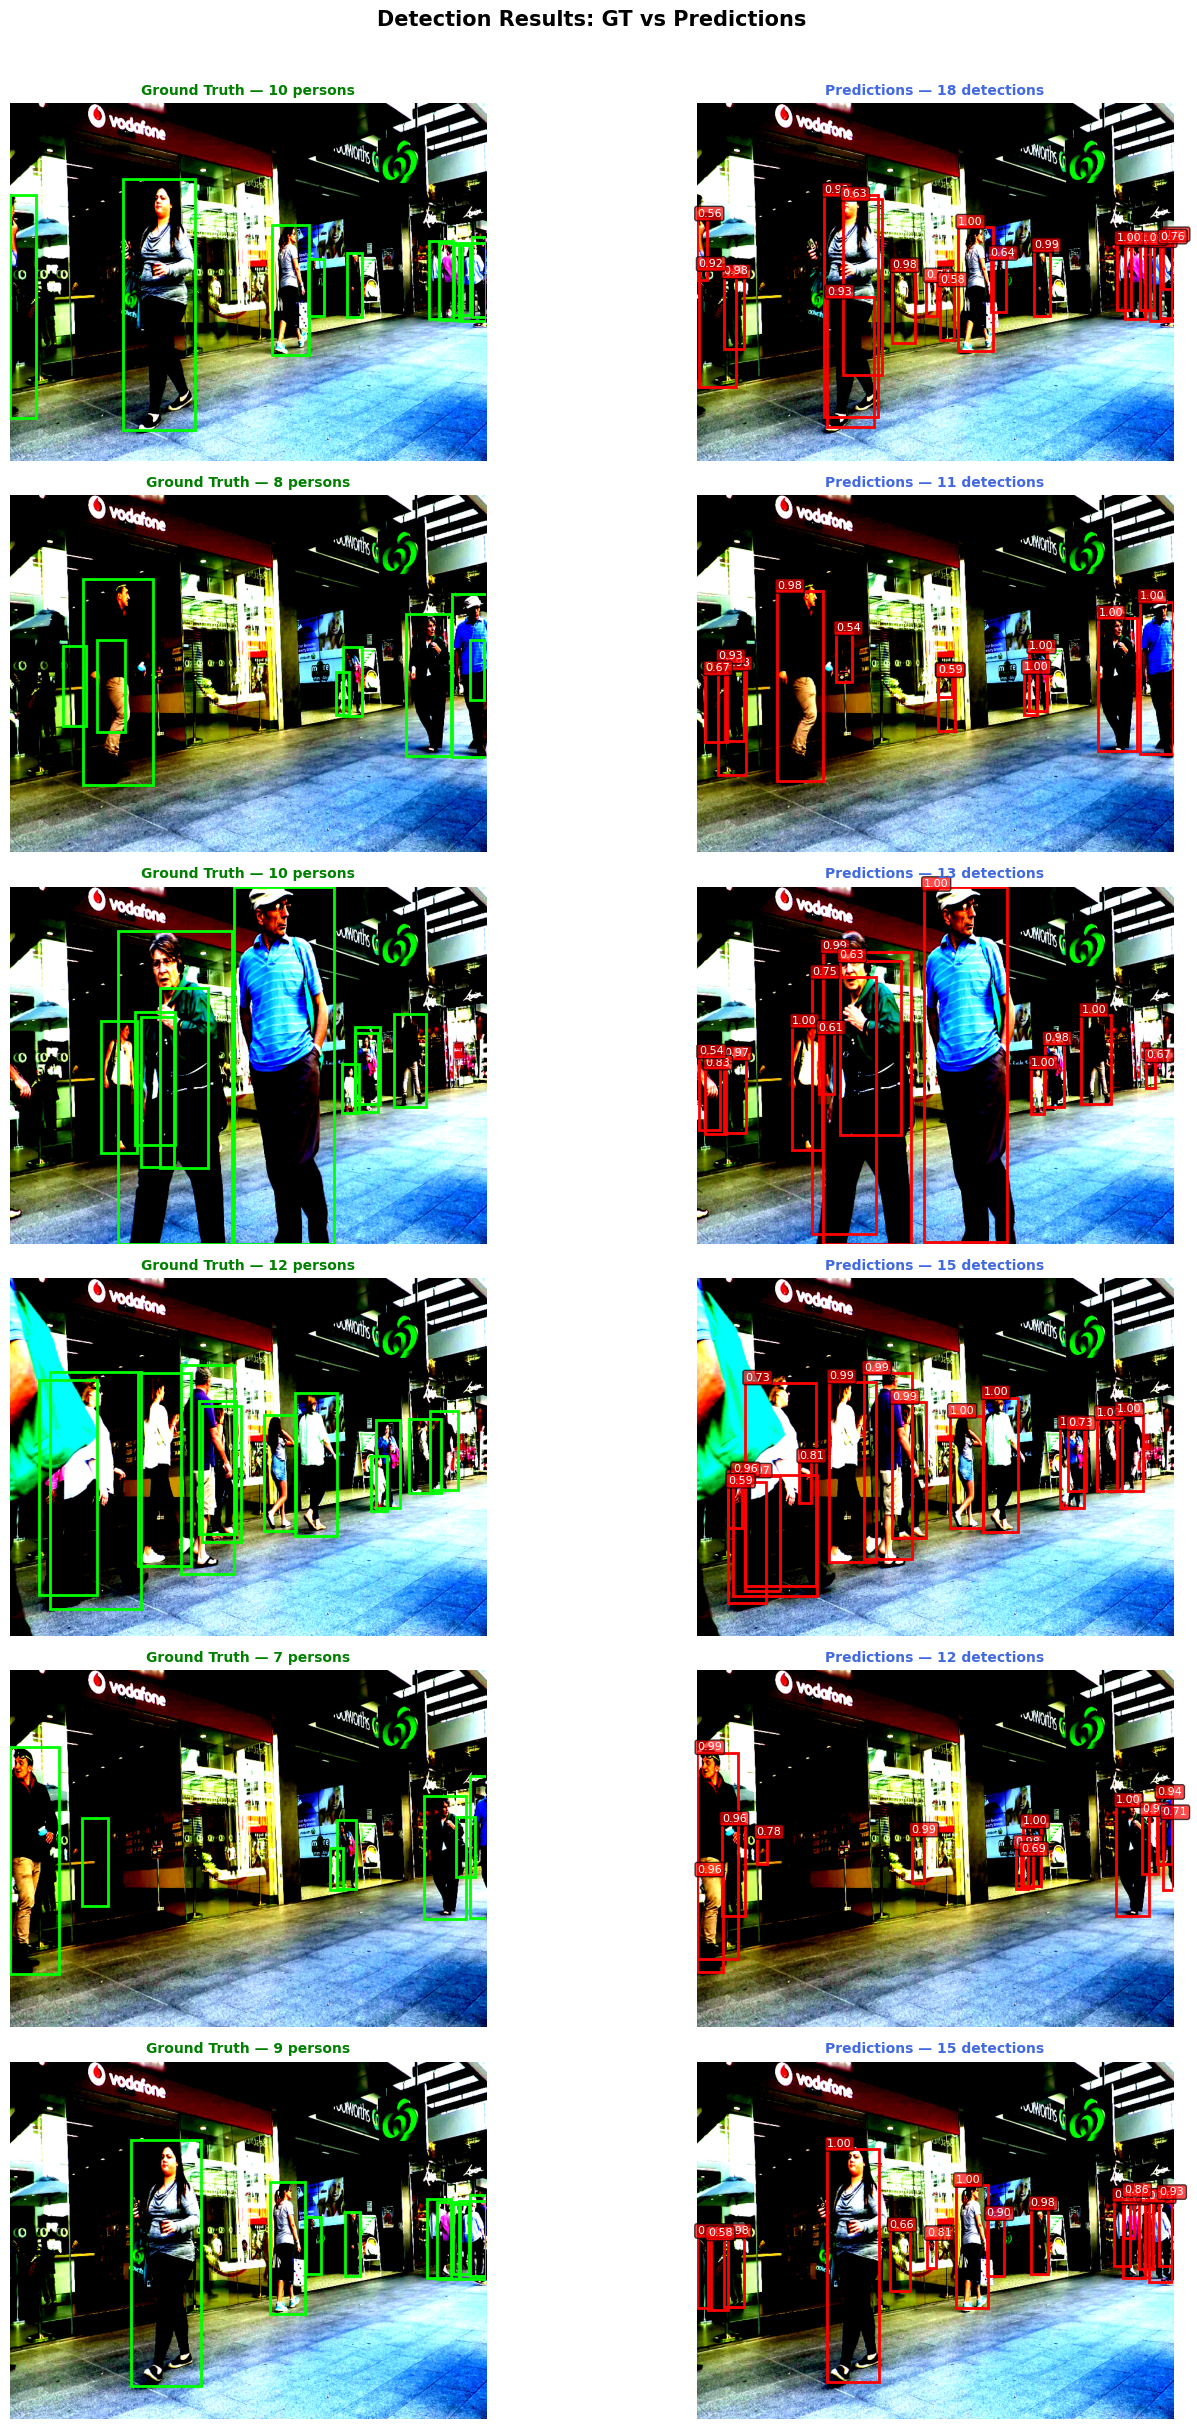


⏳ Plotting PR Curve...
  💾 Saved: pr_curve.png


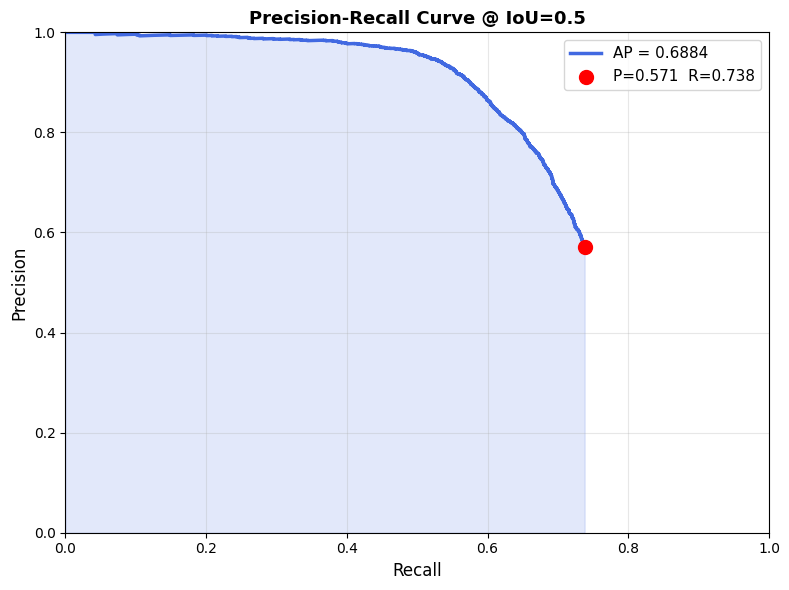


⏳ Plotting Score Distribution...
  💾 Saved: score_dist.png


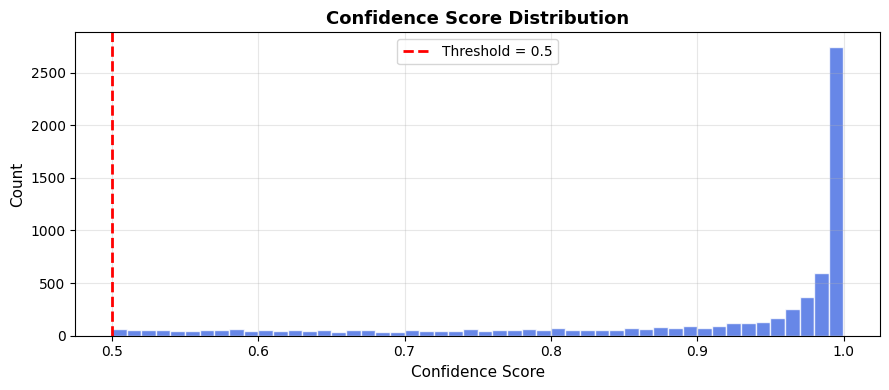


✅ Cell 10 Complete!

  Ready for Cell 11 → SORT Tracker! 🚀


In [14]:
# ============================================
# Cell 10: Evaluate & Visualize
# ============================================

import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import os
from collections import defaultdict

# ============================================
# Step 1: Load Best Model
# ============================================

def load_best_model(model, device):
    """
    Loads best saved model weights
    """
    best_model_path = os.path.join(
        SAVE_PATH, 'best_model.pth'
    )

    print("⏳ Loading Best Model...")

    if not os.path.exists(best_model_path):
        print(f"  ❌ Not found: {best_model_path}")
        print(f"  ⚠️  Using current model weights")
        return model

    checkpoint = torch.load(
        best_model_path,
        map_location = device
    )

    model.load_state_dict(
        checkpoint['model_state']
    )

    print(f"  ✅ Loaded best model!")
    print(f"     Epoch    : {checkpoint['epoch']}")
    print(f"     Val Loss : {checkpoint['val_loss']:.4f}")

    return model


# ============================================
# Step 2: IoU Calculator
# ============================================

def compute_iou(box_a, box_b):
    """
    Computes IoU between two boxes
    box format: [x1, y1, x2, y2]
    """
    # Intersection
    x1 = max(box_a[0], box_b[0])
    y1 = max(box_a[1], box_b[1])
    x2 = min(box_a[2], box_b[2])
    y2 = min(box_a[3], box_b[3])

    inter = max(0, x2 - x1) * max(0, y2 - y1)

    # Union
    area_a = (
        (box_a[2] - box_a[0]) *
        (box_a[3] - box_a[1])
    )
    area_b = (
        (box_b[2] - box_b[0]) *
        (box_b[3] - box_b[1])
    )
    union  = area_a + area_b - inter

    if union <= 0:
        return 0.0

    return inter / union


# ============================================
# Step 3: Compute Precision & Recall
# ============================================

def compute_precision_recall(
        all_preds, all_targets,
        iou_threshold=0.5):
    """
    Computes Precision, Recall, AP

    Args:
        all_preds   : list of dicts
                      {'boxes', 'scores', 'labels'}
        all_targets : list of dicts
                      {'boxes', 'labels'}
        iou_threshold: float (default 0.5)

    Returns:
        dict with precision, recall, AP, F1
    """
    tp_list    = []
    fp_list    = []
    scores_list= []
    n_gt       = 0

    for preds, targets in zip(
            all_preds, all_targets):

        pred_boxes  = preds['boxes']
        pred_scores = preds['scores']
        gt_boxes    = targets['boxes']

        n_gt       += len(gt_boxes)
        matched     = [False] * len(gt_boxes)

        # Sort by confidence score
        order = np.argsort(
            -pred_scores.numpy()
        )

        for idx in order:
            pb    = pred_boxes[idx].numpy()
            score = pred_scores[idx].item()
            scores_list.append(score)

            best_iou = 0.0
            best_j   = -1

            for j, gb in enumerate(gt_boxes):
                iou = compute_iou(
                    pb, gb.numpy()
                )
                if iou > best_iou:
                    best_iou = iou
                    best_j   = j

            if (best_iou >= iou_threshold
                    and best_j >= 0
                    and not matched[best_j]):
                tp_list.append(1)
                fp_list.append(0)
                matched[best_j] = True
            else:
                tp_list.append(0)
                fp_list.append(1)

    if len(tp_list) == 0:
        return {
            'precision' : 0.0,
            'recall'    : 0.0,
            'ap'        : 0.0,
            'f1'        : 0.0
        }

    # Sort by score
    order      = np.argsort(
        -np.array(scores_list)
    )
    tp_arr     = np.array(tp_list)[order]
    fp_arr     = np.array(fp_list)[order]

    # Cumulative
    tp_cum     = np.cumsum(tp_arr)
    fp_cum     = np.cumsum(fp_arr)

    recalls    = tp_cum / max(n_gt, 1)
    precisions = tp_cum / (tp_cum + fp_cum + 1e-6)

    # AP using trapezoidal rule
    ap = np.trapz(precisions, recalls)

    # Final P, R at threshold 0.5
    precision  = precisions[-1] if len(precisions) > 0 else 0
    recall     = recalls[-1]    if len(recalls)    > 0 else 0
    f1         = (
        2 * precision * recall /
        max(precision + recall, 1e-6)
    )

    return {
        'precision'  : float(precision),
        'recall'     : float(recall),
        'ap'         : float(ap),
        'f1'         : float(f1),
        'precisions' : precisions,
        'recalls'    : recalls
    }


# ============================================
# Step 4: Run Inference on Val Set
# ============================================

def run_inference(model, loader,
                  device, conf_threshold=0.5):
    """
    Runs model inference on full val set

    Returns:
        all_preds   : list of predictions
        all_targets : list of ground truths
    """
    model.eval()

    all_preds   = []
    all_targets = []

    print("⏳ Running Inference on Val Set...")

    with torch.no_grad():
        for batch_idx, (frames, targets) in \
                enumerate(loader):

            frames = [f.to(device) for f in frames]

            try:
                outputs = model(frames)
            except Exception as e:
                print(f"  ⚠️  Batch {batch_idx} "
                      f"skipped: {str(e)[:50]}")
                continue

            for output, target in \
                    zip(outputs, targets):

                # Filter by confidence
                keep = (
                    output['scores'] >= conf_threshold
                )

                all_preds.append({
                    'boxes'  : output['boxes'][keep].cpu(),
                    'scores' : output['scores'][keep].cpu(),
                    'labels' : output['labels'][keep].cpu()
                })
                all_targets.append({
                    'boxes'  : target['boxes'].cpu(),
                    'labels' : target['labels'].cpu()
                })

            if (batch_idx + 1) % 20 == 0:
                print(f"  Processed "
                      f"{batch_idx+1}/"
                      f"{len(loader)} batches...")

    print(f"  ✅ Inference complete!")
    print(f"     Total samples : {len(all_preds)}")

    return all_preds, all_targets


# ============================================
# Step 5: Visualize Detections
# ============================================

def visualize_detections(
        model, dataset, device,
        n_samples=6,
        conf_threshold=0.5):
    """
    Visualizes model detections vs ground truth
    """
    model.eval()

    fig, axes = plt.subplots(
        n_samples, 2,
        figsize = (16, n_samples * 4)
    )
    fig.suptitle(
        'Detection Results: GT vs Predictions',
        fontsize   = 15,
        fontweight = 'bold',
        y          = 1.01
    )

    # Pick random samples
    indices = np.random.choice(
        len(dataset),
        size    = n_samples,
        replace = False
    )

    # Disable augmentation
    original          = dataset.is_train
    dataset.is_train  = False

    for row, idx in enumerate(indices):

        frame, target = dataset[idx]

        # ---- Ground Truth ----
        ax_gt  = axes[row][0]
        img_np = frame.permute(1, 2, 0).numpy()
        img_np = np.clip(img_np, 0, 1)

        ax_gt.imshow(img_np)
        ax_gt.set_title(
            f'Ground Truth — '
            f'{len(target["boxes"])} persons',
            fontsize = 10,
            color    = 'green',
            fontweight = 'bold'
        )
        ax_gt.axis('off')

        for box in target['boxes']:
            x1, y1, x2, y2 = box.numpy()
            rect = patches.Rectangle(
                (x1, y1),
                x2 - x1, y2 - y1,
                linewidth = 2,
                edgecolor = 'lime',
                facecolor = 'none'
            )
            ax_gt.add_patch(rect)

        # ---- Predictions ----
        ax_pd  = axes[row][1]
        ax_pd.imshow(img_np)

        with torch.no_grad():
            output = model(
                [frame.to(device)]
            )[0]

        keep = (
            output['scores'] >= conf_threshold
        )
        pred_boxes  = output['boxes'][keep].cpu()
        pred_scores = output['scores'][keep].cpu()

        ax_pd.set_title(
            f'Predictions — '
            f'{len(pred_boxes)} detections',
            fontsize = 10,
            color    = 'royalblue',
            fontweight = 'bold'
        )
        ax_pd.axis('off')

        for box, score in zip(
                pred_boxes, pred_scores):
            x1, y1, x2, y2 = box.numpy()
            rect = patches.Rectangle(
                (x1, y1),
                x2 - x1, y2 - y1,
                linewidth = 2,
                edgecolor = 'red',
                facecolor = 'none'
            )
            ax_pd.add_patch(rect)

            ax_pd.text(
                x1, max(y1 - 4, 0),
                f'{score:.2f}',
                fontsize  = 8,
                color     = 'white',
                bbox      = dict(
                    boxstyle  = 'round,pad=0.2',
                    facecolor = 'red',
                    alpha     = 0.7
                )
            )

    dataset.is_train = original

    plt.tight_layout()
    save_path = os.path.join(
        SAVE_PATH, 'detections.png'
    )
    plt.savefig(save_path, dpi=150,
                bbox_inches='tight')
    print(f"\n  💾 Saved: detections.png")
    plt.show()


# ============================================
# Step 6: Plot PR Curve
# ============================================

def plot_pr_curve(metrics):
    """
    Plots Precision-Recall curve
    """
    fig, ax = plt.subplots(figsize=(8, 6))

    if 'precisions' in metrics:
        ax.plot(
            metrics['recalls'],
            metrics['precisions'],
            color     = 'royalblue',
            linewidth = 2.5,
            label     = f"AP = {metrics['ap']:.4f}"
        )
        ax.fill_between(
            metrics['recalls'],
            metrics['precisions'],
            alpha = 0.15,
            color = 'royalblue'
        )

    # Marks
    ax.scatter(
        [metrics['recall']],
        [metrics['precision']],
        color  = 'red',
        s      = 100,
        zorder = 5,
        label  = f"P={metrics['precision']:.3f}"
                 f"  R={metrics['recall']:.3f}"
    )

    ax.set_title(
        'Precision-Recall Curve @ IoU=0.5',
        fontsize   = 13,
        fontweight = 'bold'
    )
    ax.set_xlabel('Recall',    fontsize=12)
    ax.set_ylabel('Precision', fontsize=12)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    save_path = os.path.join(
        SAVE_PATH, 'pr_curve.png'
    )
    plt.savefig(save_path, dpi=150,
                bbox_inches='tight')
    print(f"  💾 Saved: pr_curve.png")
    plt.show()


# ============================================
# Step 7: Score Distribution Plot
# ============================================

def plot_score_distribution(all_preds):
    """
    Plots histogram of confidence scores
    """
    all_scores = []
    for pred in all_preds:
        all_scores.extend(
            pred['scores'].numpy().tolist()
        )

    fig, ax = plt.subplots(figsize=(9, 4))

    ax.hist(
        all_scores,
        bins      = 50,
        color     = 'royalblue',
        edgecolor = 'white',
        alpha     = 0.8
    )
    ax.axvline(
        x         = 0.5,
        color     = 'red',
        linestyle = '--',
        linewidth = 2,
        label     = 'Threshold = 0.5'
    )
    ax.set_title(
        'Confidence Score Distribution',
        fontsize   = 13,
        fontweight = 'bold'
    )
    ax.set_xlabel('Confidence Score', fontsize=11)
    ax.set_ylabel('Count',            fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    save_path = os.path.join(
        SAVE_PATH, 'score_dist.png'
    )
    plt.savefig(save_path, dpi=150,
                bbox_inches='tight')
    print(f"  💾 Saved: score_dist.png")
    plt.show()


# ============================================
# Step 8: Run Full Evaluation
# ============================================

print("=" * 55)
print("🚀 Cell 10: Evaluate & Visualize")
print("=" * 55)

# Load best model
model = load_best_model(model, DEVICE)

# Run inference
all_preds, all_targets = run_inference(
    model          = model,
    loader         = val_loader,
    device         = DEVICE,
    conf_threshold = CONF_THRESHOLD
)

# Compute metrics
print("\n⏳ Computing Metrics...")
metrics = compute_precision_recall(
    all_preds     = all_preds,
    all_targets   = all_targets,
    iou_threshold = 0.5
)

# Print metrics
print(f"\n{'='*45}")
print(f"📊 Evaluation Results @ IoU=0.5")
print(f"{'='*45}")
print(f"  Precision : {metrics['precision']:.4f}")
print(f"  Recall    : {metrics['recall']:.4f}")
print(f"  F1 Score  : {metrics['f1']:.4f}")
print(f"  mAP@0.5   : {metrics['ap']:.4f}")
print(f"{'='*45}")

# Visualize detections
print("\n⏳ Visualizing Detections...")
visualize_detections(
    model          = model,
    dataset        = val_dataset,
    device         = DEVICE,
    n_samples      = 6,
    conf_threshold = CONF_THRESHOLD
)

# PR Curve
print("\n⏳ Plotting PR Curve...")
plot_pr_curve(metrics)

# Score Distribution
print("\n⏳ Plotting Score Distribution...")
plot_score_distribution(all_preds)

print(f"\n{'='*55}")
print(f"✅ Cell 10 Complete!")
print(f"{'='*55}")
print(f"\n  Ready for Cell 11 → SORT Tracker! 🚀")


In [15]:
# ============================================
# Cell 11: SORT Tracker
# ============================================

# ============================================
# Step 1: Install SORT Dependencies
# ============================================

import subprocess
import sys

print("⏳ Installing SORT Dependencies...")

packages = [
    'filterpy',
    'scikit-image',
    'lap'
]

for pkg in packages:
    try:
        subprocess.check_call([
            sys.executable, '-m',
            'pip', 'install', pkg, '-q'
        ])
        print(f"  ✅ Installed: {pkg}")
    except Exception as e:
        print(f"  ⚠️  Failed: {pkg} → {e}")

print("✅ Dependencies Ready!")


# ============================================
# Step 2: Kalman Filter Tracker
# ============================================

import numpy as np
from filterpy.kalman import KalmanFilter

class KalmanBoxTracker:
    """
    Tracks a single object using
    Kalman Filter

    State vector:
    [x1, y1, x2, y2, dx, dy, ds]

    where:
    x1,y1 = top-left corner
    x2,y2 = bottom-right corner
    dx,dy = velocity
    ds    = scale change rate
    """

    count = 0  # Global track ID counter

    def __init__(self, bbox):
        """
        bbox: [x1, y1, x2, y2]
        """

        # ---- Kalman Filter Setup ----
        # 7 state dims, 4 measurement dims
        self.kf = KalmanFilter(
            dim_x = 7,
            dim_z = 4
        )

        # State transition matrix
        self.kf.F = np.array([
            [1,0,0,0,1,0,0],
            [0,1,0,0,0,1,0],
            [0,0,1,0,0,0,1],
            [0,0,0,1,0,0,0],
            [0,0,0,0,1,0,0],
            [0,0,0,0,0,1,0],
            [0,0,0,0,0,0,1]
        ], dtype=float)

        # Measurement matrix
        self.kf.H = np.array([
            [1,0,0,0,0,0,0],
            [0,1,0,0,0,0,0],
            [0,0,1,0,0,0,0],
            [0,0,0,1,0,0,0]
        ], dtype=float)

        # Measurement noise
        self.kf.R[2:, 2:] *= 10.0

        # Covariance matrix
        self.kf.P[4:, 4:] *= 1000.0
        self.kf.P         *= 10.0

        # Process noise
        self.kf.Q[-1, -1] *= 0.01
        self.kf.Q[4:, 4:] *= 0.01

        # Initial state
        self.kf.x[:4] = self._bbox_to_z(bbox)

        # Track metadata
        self.id            = KalmanBoxTracker.count
        KalmanBoxTracker.count += 1

        self.hits          = 1
        self.hit_streak    = 1
        self.age           = 0
        self.time_since_update = 0
        self.history       = []

    def _bbox_to_z(self, bbox):
        """
        [x1,y1,x2,y2] → [x1,y1,x2,y2]
        as column vector
        """
        return np.array([
            [bbox[0]],
            [bbox[1]],
            [bbox[2]],
            [bbox[3]]
        ], dtype=float)

    def _x_to_bbox(self, x):
        """
        State vector → [x1,y1,x2,y2]
        """
        return np.array([
            x[0, 0],
            x[1, 0],
            x[2, 0],
            x[3, 0]
        ])

    def predict(self):
        """
        Advances state using Kalman predict
        Returns predicted bbox
        """
        self.kf.predict()
        self.age              += 1
        self.time_since_update += 1
        self.history.append(
            self._x_to_bbox(self.kf.x)
        )
        return self.history[-1]

    def update(self, bbox):
        """
        Updates tracker with new detection
        """
        self.time_since_update = 0
        self.hits             += 1
        self.hit_streak       += 1
        self.history           = []
        self.kf.update(
            self._bbox_to_z(bbox)
        )

    def get_state(self):
        """
        Returns current bbox estimate
        """
        return self._x_to_bbox(self.kf.x)


# ============================================
# Step 3: IoU Matrix Calculator
# ============================================

def iou_batch(bb_test, bb_gt):
    """
    Computes IoU between all pairs of
    predicted and GT boxes

    Args:
        bb_test : (N, 4) predicted boxes
        bb_gt   : (M, 4) ground truth boxes

    Returns:
        iou_matrix : (N, M)
    """
    bb_gt   = np.expand_dims(bb_gt,   0)
    bb_test = np.expand_dims(bb_test, 1)

    xx1 = np.maximum(bb_test[..., 0],
                     bb_gt[...,   0])
    yy1 = np.maximum(bb_test[..., 1],
                     bb_gt[...,   1])
    xx2 = np.minimum(bb_test[..., 2],
                     bb_gt[...,   2])
    yy2 = np.minimum(bb_test[..., 3],
                     bb_gt[...,   3])

    w   = np.maximum(0.0, xx2 - xx1)
    h   = np.maximum(0.0, yy2 - yy1)

    inter = w * h

    area_test = (
        (bb_test[..., 2] - bb_test[..., 0]) *
        (bb_test[..., 3] - bb_test[..., 1])
    )
    area_gt = (
        (bb_gt[..., 2] - bb_gt[..., 0]) *
        (bb_gt[..., 3] - bb_gt[..., 1])
    )

    union = (
        area_test + area_gt - inter + 1e-6
    )

    return inter / union


# ============================================
# Step 4: Hungarian Assignment
# ============================================

def associate_detections(
        detections, trackers,
        iou_threshold=0.3):
    """
    Matches detections to existing trackers
    using Hungarian algorithm + IoU

    Returns:
        matched      : (N,2) matched pairs
        unmatched_det: unmatched detections
        unmatched_trk: unmatched trackers
    """
    if len(trackers) == 0:
        return (
            np.empty((0, 2), dtype=int),
            np.arange(len(detections)),
            np.empty((0,),   dtype=int)
        )

    iou_matrix = iou_batch(
        detections, trackers
    )

    if min(iou_matrix.shape) > 0:
        # Hungarian matching
        from scipy.optimize import \
            linear_sum_assignment
        row_ind, col_ind = \
            linear_sum_assignment(-iou_matrix)
        matched_indices = np.stack(
            [row_ind, col_ind], axis=1
        )
    else:
        matched_indices = np.empty(
            (0, 2), dtype=int
        )

    # Find unmatched detections
    unmatched_det = []
    for d in range(len(detections)):
        if d not in matched_indices[:, 0]:
            unmatched_det.append(d)

    # Find unmatched trackers
    unmatched_trk = []
    for t in range(len(trackers)):
        if t not in matched_indices[:, 1]:
            unmatched_trk.append(t)

    # Filter low IoU matches
    matched = []
    for m in matched_indices:
        if iou_matrix[m[0], m[1]] < iou_threshold:
            unmatched_det.append(m[0])
            unmatched_trk.append(m[1])
        else:
            matched.append(m.reshape(1, 2))

    if len(matched) == 0:
        matched = np.empty((0, 2), dtype=int)
    else:
        matched = np.concatenate(matched, axis=0)

    return (
        matched,
        np.array(unmatched_det),
        np.array(unmatched_trk)
    )


# ============================================
# Step 5: SORT Tracker Class
# ============================================

class SORTTracker:
    """
    SORT: Simple Online and Realtime Tracking

    Args:
        max_age     : frames before track deleted
        min_hits    : min hits before track shown
        iou_threshold: min IoU for association
    """

    def __init__(
            self,
            max_age       = 5,
            min_hits      = 3,
            iou_threshold = 0.3):

        self.max_age       = max_age
        self.min_hits      = min_hits
        self.iou_threshold = iou_threshold
        self.trackers      = []
        self.frame_count   = 0

        # Reset track ID counter
        KalmanBoxTracker.count = 0

    def update(self, detections):
        """
        Updates tracker with new detections

        Args:
            detections: (N,5) array
                        [x1,y1,x2,y2,score]

        Returns:
            tracks: (M,5) array
                    [x1,y1,x2,y2,track_id]
        """
        self.frame_count += 1

        # ---- Predict existing trackers ----
        trk_preds = []
        to_delete = []

        for i, trk in enumerate(self.trackers):
            pred = trk.predict()
            if np.any(np.isnan(pred)):
                to_delete.append(i)
            else:
                trk_preds.append(pred)

        # Remove invalid trackers
        for i in reversed(to_delete):
            self.trackers.pop(i)

        trk_arr = np.array(trk_preds) \
            if trk_preds \
            else np.empty((0, 4))

        # ---- Associate detections ----
        det_arr = detections[:, :4] \
            if len(detections) > 0 \
            else np.empty((0, 4))

        matched, unmatched_det, unmatched_trk \
            = associate_detections(
                det_arr, trk_arr,
                self.iou_threshold
            )

        # ---- Update matched trackers ----
        for m in matched:
            self.trackers[m[1]].update(
                detections[m[0], :4]
            )

        # ---- Create new trackers ----
        for d in unmatched_det:
            trk = KalmanBoxTracker(
                detections[d, :4]
            )
            self.trackers.append(trk)

        # ---- Collect active tracks ----
        results  = []
        to_delete = []

        for i, trk in enumerate(self.trackers):
            state = trk.get_state()

            # Only return confirmed tracks
            if (
                trk.time_since_update < 1
                and (
                    trk.hit_streak >= self.min_hits
                    or self.frame_count <= self.min_hits
                )
            ):
                results.append(
                    np.concatenate(
                        [state, [trk.id + 1]]
                    )
                )

            # Mark dead tracks
            if trk.time_since_update > self.max_age:
                to_delete.append(i)

        # Remove dead tracks
        for i in reversed(to_delete):
            self.trackers.pop(i)

        return np.array(results) \
            if results \
            else np.empty((0, 5))


# ============================================
# Step 6: Color Generator for Track IDs
# ============================================

def get_track_color(track_id):
    """
    Returns unique color per track ID
    """
    colors = [
        '#FF6B6B', '#4ECDC4', '#45B7D1',
        '#96CEB4', '#FFEAA7', '#DDA0DD',
        '#98D8C8', '#F7DC6F', '#BB8FCE',
        '#85C1E9', '#F0B27A', '#82E0AA',
        '#F1948A', '#85929E', '#73C6B6',
        '#F8C471', '#AED6F1', '#A9DFBF',
        '#FAD7A0', '#D2B4DE'
    ]
    return colors[track_id % len(colors)]


# ============================================
# Step 7: Run SORT on Val Sequence
# ============================================

def run_sort_on_sequence(
        model, dataset, device,
        start_idx     = 0,
        n_frames      = 50,
        conf_threshold= 0.5,
        max_age       = 5,
        min_hits      = 3,
        iou_threshold = 0.3):
    """
    Runs SORT tracker on a sequence of frames

    Returns:
        frame_results: list of track results
                       per frame
    """
    model.eval()

    tracker      = SORTTracker(
        max_age       = max_age,
        min_hits      = min_hits,
        iou_threshold = iou_threshold
    )

    frame_results = []

    # Disable augmentation
    original          = dataset.is_train
    dataset.is_train  = False

    end_idx = min(
        start_idx + n_frames,
        len(dataset)
    )

    print(f"⏳ Running SORT on frames "
          f"{start_idx} → {end_idx}...")

    for idx in range(start_idx, end_idx):

        frame, target = dataset[idx]

        # ---- Run Detector ----
        with torch.no_grad():
            output = model(
                [frame.to(device)]
            )[0]

        # ---- Filter by Confidence ----
        keep = output['scores'] >= conf_threshold

        boxes  = output['boxes'][keep].cpu().numpy()
        scores = output['scores'][keep].cpu().numpy()

        # ---- Format for SORT ----
        if len(boxes) > 0:
            detections = np.column_stack(
                [boxes, scores]
            )
        else:
            detections = np.empty((0, 5))

        # ---- Update Tracker ----
        tracks = tracker.update(detections)

        frame_results.append({
            'frame'      : idx,
            'image'      : frame,
            'tracks'     : tracks,
            'detections' : detections,
            'gt_boxes'   : target['boxes'].numpy()
        })

        if (idx - start_idx + 1) % 10 == 0:
            n_tracks = len(tracks)
            n_dets   = len(detections)
            print(f"  Frame {idx:4d} | "
                  f"Detections: {n_dets:3d} | "
                  f"Tracks: {n_tracks:3d}")

    dataset.is_train = original

    print(f"\n  ✅ SORT complete!")
    print(f"     Frames processed: "
          f"{end_idx - start_idx}")

    return frame_results


# ============================================
# Step 8: Visualize SORT Results
# ============================================

def visualize_sort_results(
        frame_results,
        n_frames = 6):
    """
    Visualizes SORT tracking results
    Shows bounding boxes with track IDs
    """
    # Pick evenly spaced frames
    indices = np.linspace(
        0,
        len(frame_results) - 1,
        n_frames,
        dtype = int
    )

    fig, axes = plt.subplots(
        2, 3,
        figsize = (18, 10)
    )
    axes = axes.flatten()

    fig.suptitle(
        '🎯 SORT Tracker Results',
        fontsize   = 15,
        fontweight = 'bold'
    )

    for plot_idx, frame_idx in enumerate(indices):

        result = frame_results[frame_idx]
        ax     = axes[plot_idx]

        # Display image
        img_np = result['image'].permute(
            1, 2, 0
        ).numpy()
        img_np = np.clip(img_np, 0, 1)
        ax.imshow(img_np)

        tracks = result['tracks']
        n_tracks = len(tracks)

        # Draw tracks
        for track in tracks:
            x1, y1, x2, y2 = track[:4]
            track_id        = int(track[4])
            color           = get_track_color(
                track_id
            )

            # Bounding box
            rect = patches.Rectangle(
                (x1, y1),
                x2 - x1, y2 - y1,
                linewidth = 2.5,
                edgecolor = color,
                facecolor = 'none'
            )
            ax.add_patch(rect)

            # Track ID label
            ax.text(
                x1, max(y1 - 5, 0),
                f'ID:{track_id}',
                fontsize  = 8,
                color     = 'white',
                fontweight= 'bold',
                bbox      = dict(
                    boxstyle  = 'round,pad=0.3',
                    facecolor = color,
                    alpha     = 0.85
                )
            )

        ax.set_title(
            f'Frame {result["frame"]} — '
            f'{n_tracks} Tracks',
            fontsize   = 10,
            fontweight = 'bold'
        )
        ax.axis('off')

    plt.tight_layout()
    save_path = os.path.join(
        SAVE_PATH, 'sort_results.png'
    )
    plt.savefig(save_path, dpi=150,
                bbox_inches='tight')
    print(f"\n  💾 Saved: sort_results.png")
    plt.show()


# ============================================
# Step 9: Track Statistics
# ============================================

def compute_track_stats(frame_results):
    """
    Computes statistics about tracking
    """
    total_tracks  = set()
    total_dets    = 0
    frames_active = []

    for result in frame_results:
        tracks = result['tracks']
        dets   = result['detections']

        for track in tracks:
            total_tracks.add(int(track[4]))

        total_dets    += len(dets)
        frames_active.append(len(tracks))

    avg_tracks = np.mean(frames_active)
    max_tracks = np.max(frames_active)
    min_tracks = np.min(frames_active)

    print(f"\n{'='*45}")
    print(f"📊 SORT Tracking Statistics")
    print(f"{'='*45}")
    print(f"  Total Frames    : {len(frame_results)}")
    print(f"  Unique Track IDs: {len(total_tracks)}")
    print(f"  Total Detections: {total_dets}")
    print(f"  Avg Tracks/Frame: {avg_tracks:.1f}")
    print(f"  Max Tracks/Frame: {max_tracks}")
    print(f"  Min Tracks/Frame: {min_tracks}")
    print(f"{'='*45}")

    # Plot tracks per frame
    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(
        range(len(frame_results)),
        frames_active,
        color     = 'royalblue',
        linewidth = 2.0,
        label     = 'Active Tracks'
    )
    ax.fill_between(
        range(len(frame_results)),
        frames_active,
        alpha = 0.2,
        color = 'royalblue'
    )
    ax.axhline(
        avg_tracks,
        color     = 'red',
        linestyle = '--',
        linewidth = 1.5,
        label     = f'Avg: {avg_tracks:.1f}'
    )

    ax.set_title(
        'Active Tracks Per Frame',
        fontsize   = 13,
        fontweight = 'bold'
    )
    ax.set_xlabel('Frame Index', fontsize=11)
    ax.set_ylabel('Active Tracks', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    save_path = os.path.join(
        SAVE_PATH, 'tracks_per_frame.png'
    )
    plt.savefig(save_path, dpi=150,
                bbox_inches='tight')
    print(f"  💾 Saved: tracks_per_frame.png")
    plt.show()


# ============================================
# Step 10: Run Everything
# ============================================

print("=" * 55)
print("🚀 Cell 11: SORT Tracker")
print("=" * 55)

# Run SORT on val sequence
frame_results = run_sort_on_sequence(
    model          = model,
    dataset        = val_dataset,
    device         = DEVICE,
    start_idx      = 0,
    n_frames       = 50,
    conf_threshold = CONF_THRESHOLD,
    max_age        = 5,
    min_hits       = 3,
    iou_threshold  = 0.3
)

# Visualize results
print("\n⏳ Visualizing Results...")
visualize_sort_results(
    frame_results,
    n_frames = 6
)

# Compute statistics
compute_track_stats(frame_results)

print(f"\n{'='*55}")
print(f"✅ Cell 11 Complete!")
print(f"{'='*55}")
print(f"\n🎉 All Cells Done!")
print(f"   Faster R-CNN + SORT Tracker Ready!")


Output hidden; open in https://colab.research.google.com to view.

In [17]:
# ============================================
# Quick Directory Scanner
# ============================================

import os

print("📂 Everything in /content/:")
print("=" * 50)

for item in os.listdir('/content'):
    full_path = os.path.join('/content', item)
    if os.path.isdir(full_path):
        print(f"  📁 {item}/")
        # Show what's inside each folder
        try:
            sub_items = os.listdir(full_path)
            for sub in sub_items[:5]:
                sub_full = os.path.join(
                    full_path, sub
                )
                kind = "📁" if os.path.isdir(
                    sub_full) else "📄"
                print(f"      {kind} {sub}")
            if len(sub_items) > 5:
                print(f"      ... "
                      f"+{len(sub_items)-5} more")
        except:
            pass
    else:
        size = os.path.getsize(full_path)
        size_mb = size / (1024 * 1024)
        print(f"  📄 {item} "
              f"({size_mb:.1f} MB)")

print("\n" + "=" * 50)

# Also print your config variables
print("\n📋 Your Config Variables:")
print("=" * 50)
try:
    print(f"  DATA_PATH : {DATA_PATH}")
except:
    print("  DATA_PATH : ❌ Not defined")
try:
    print(f"  SAVE_PATH : {SAVE_PATH}")
except:
    print("  SAVE_PATH : ❌ Not defined")
try:
    print(f"  ROOT_DIR  : {ROOT_DIR}")
except:
    print("  ROOT_DIR  : ❌ Not defined")


📂 Everything in /content/:
  📁 .config/
      📄 gce
      📄 hidden_gcloud_config_universe_descriptor_data_cache_configs.db
      📄 active_config
      📁 configurations
      📁 logs
      ... +5 more
  📄 MOT17.zip (5588.7 MB)
  📁 checkpoints/
      📄 lr_schedule.png
      📄 tracks_per_frame.png
      📄 component_losses.png
      📄 pr_curve.png
      📄 score_dist.png
      ... +6 more
  📁 MOT17/
      📁 MOT17
  📁 sample_data/
      📄 README.md
      📄 anscombe.json
      📄 mnist_train_small.csv
      📄 california_housing_train.csv
      📄 mnist_test.csv
      ... +1 more


📋 Your Config Variables:
  DATA_PATH : ❌ Not defined
  SAVE_PATH : /content/checkpoints
  ROOT_DIR  : ❌ Not defined


In [18]:
# ============================================
# Step 1: Verify Correct Path
# ============================================

import os

mot_path = '/content/MOT17/MOT17/train'

print("🔍 Checking Correct Path...")
print("=" * 50)

if os.path.exists(mot_path):
    print(f"✅ Found MOT17 train folder!")
    sequences = sorted(os.listdir(mot_path))
    print(f"\n📂 Available Sequences:")
    for seq in sequences:
        img_path = os.path.join(
            mot_path, seq, 'img1'
        )
        if os.path.exists(img_path):
            n_frames = len(
                os.listdir(img_path)
            )
            print(f"  ✅ {seq} "
                  f"→ {n_frames} frames")
        else:
            print(f"  ⚠️  {seq} "
                  f"→ no img1 folder")
else:
    print(f"❌ Still not found!")
    print(f"   Checking one level up...")
    alt = '/content/MOT17/MOT17'
    if os.path.exists(alt):
        print(f"   Found: {alt}")
        for item in os.listdir(alt):
            print(f"   📁 {item}")


🔍 Checking Correct Path...
✅ Found MOT17 train folder!

📂 Available Sequences:
  ✅ MOT17-02-DPM → 600 frames
  ✅ MOT17-02-FRCNN → 600 frames
  ✅ MOT17-02-SDP → 600 frames
  ✅ MOT17-04-DPM → 1050 frames
  ✅ MOT17-04-FRCNN → 1050 frames
  ✅ MOT17-04-SDP → 1050 frames
  ✅ MOT17-05-DPM → 837 frames
  ✅ MOT17-05-FRCNN → 837 frames
  ✅ MOT17-05-SDP → 837 frames
  ✅ MOT17-09-DPM → 525 frames
  ✅ MOT17-09-FRCNN → 525 frames
  ✅ MOT17-09-SDP → 525 frames
  ✅ MOT17-10-DPM → 654 frames
  ✅ MOT17-10-FRCNN → 654 frames
  ✅ MOT17-10-SDP → 654 frames
  ✅ MOT17-11-DPM → 900 frames
  ✅ MOT17-11-FRCNN → 900 frames
  ✅ MOT17-11-SDP → 900 frames
  ✅ MOT17-13-DPM → 750 frames
  ✅ MOT17-13-FRCNN → 750 frames
  ✅ MOT17-13-SDP → 750 frames


In [21]:
# ============================================
# Step 1: Verify Correct Path
# ============================================

import os

mot_path = '/content/MOT17/MOT17/train'

print("🔍 Checking Correct Path...")
print("=" * 50)

if os.path.exists(mot_path):
    print(f"✅ Found MOT17 train folder!")
    sequences = sorted(os.listdir(mot_path))
    print(f"\n📂 Available Sequences:")
    for seq in sequences:
        img_path = os.path.join(
            mot_path, seq, 'img1'
        )
        if os.path.exists(img_path):
            n_frames = len(
                os.listdir(img_path)
            )
            print(f"  ✅ {seq} "
                  f"→ {n_frames} frames")
        else:
            print(f"  ⚠️  {seq} "
                  f"→ no img1 folder")
else:
    print(f"❌ Still not found!")
    print(f"   Checking one level up...")
    alt = '/content/MOT17/MOT17'
    if os.path.exists(alt):
        print(f"   Found: {alt}")
        for item in os.listdir(alt):
            print(f"   📁 {item}")


🔍 Checking Correct Path...
✅ Found MOT17 train folder!

📂 Available Sequences:
  ✅ MOT17-02-DPM → 600 frames
  ✅ MOT17-02-FRCNN → 600 frames
  ✅ MOT17-02-SDP → 600 frames
  ✅ MOT17-04-DPM → 1050 frames
  ✅ MOT17-04-FRCNN → 1050 frames
  ✅ MOT17-04-SDP → 1050 frames
  ✅ MOT17-05-DPM → 837 frames
  ✅ MOT17-05-FRCNN → 837 frames
  ✅ MOT17-05-SDP → 837 frames
  ✅ MOT17-09-DPM → 525 frames
  ✅ MOT17-09-FRCNN → 525 frames
  ✅ MOT17-09-SDP → 525 frames
  ✅ MOT17-10-DPM → 654 frames
  ✅ MOT17-10-FRCNN → 654 frames
  ✅ MOT17-10-SDP → 654 frames
  ✅ MOT17-11-DPM → 900 frames
  ✅ MOT17-11-FRCNN → 900 frames
  ✅ MOT17-11-SDP → 900 frames
  ✅ MOT17-13-DPM → 750 frames
  ✅ MOT17-13-FRCNN → 750 frames
  ✅ MOT17-13-SDP → 750 frames


✅ Device : cuda
✅ MOT17  : /content/MOT17/MOT17/train
✅ Save   : /content/checkpoints
🚀 Cell 12: MOT17 Video Tracker

⏳ Loading Model...
   Path: /content/checkpoints/best_model.pth

   📋 Checkpoint Keys:
      → epoch
      → model_state
      → optimizer
      → val_loss
      → history

   ✅ Loaded: model_state
   ✅ Epoch : 1
   ✅ Val Loss: 0.8207

   ✅ Model ready on cuda!

📂 Available Sequences:
  [0] MOT17-02-DPM → 600 frames
  [1] MOT17-02-FRCNN → 600 frames
  [2] MOT17-02-SDP → 600 frames
  [3] MOT17-04-DPM → 1050 frames
  [4] MOT17-04-FRCNN → 1050 frames
  [5] MOT17-04-SDP → 1050 frames
  [6] MOT17-05-DPM → 837 frames
  [7] MOT17-05-FRCNN → 837 frames
  [8] MOT17-05-SDP → 837 frames
  [9] MOT17-09-DPM → 525 frames
  [10] MOT17-09-FRCNN → 525 frames
  [11] MOT17-09-SDP → 525 frames
  [12] MOT17-10-DPM → 654 frames
  [13] MOT17-10-FRCNN → 654 frames
  [14] MOT17-10-SDP → 654 frames
  [15] MOT17-11-DPM → 900 frames
  [16] MOT17-11-FRCNN → 900 frames
  [17] MOT17-11-SDP → 900 fram

/tmp/ipykernel_275/3219777035.py:583: UserWarning: Glyph 128249 (\N{VIDEO CAMERA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_275/3219777035.py:587: UserWarning: Glyph 128249 (\N{VIDEO CAMERA}) missing from font(s) DejaVu Sans.
  plt.savefig(path, dpi=150,


  💾 Saved: video_stats.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128249 (\N{VIDEO CAMERA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


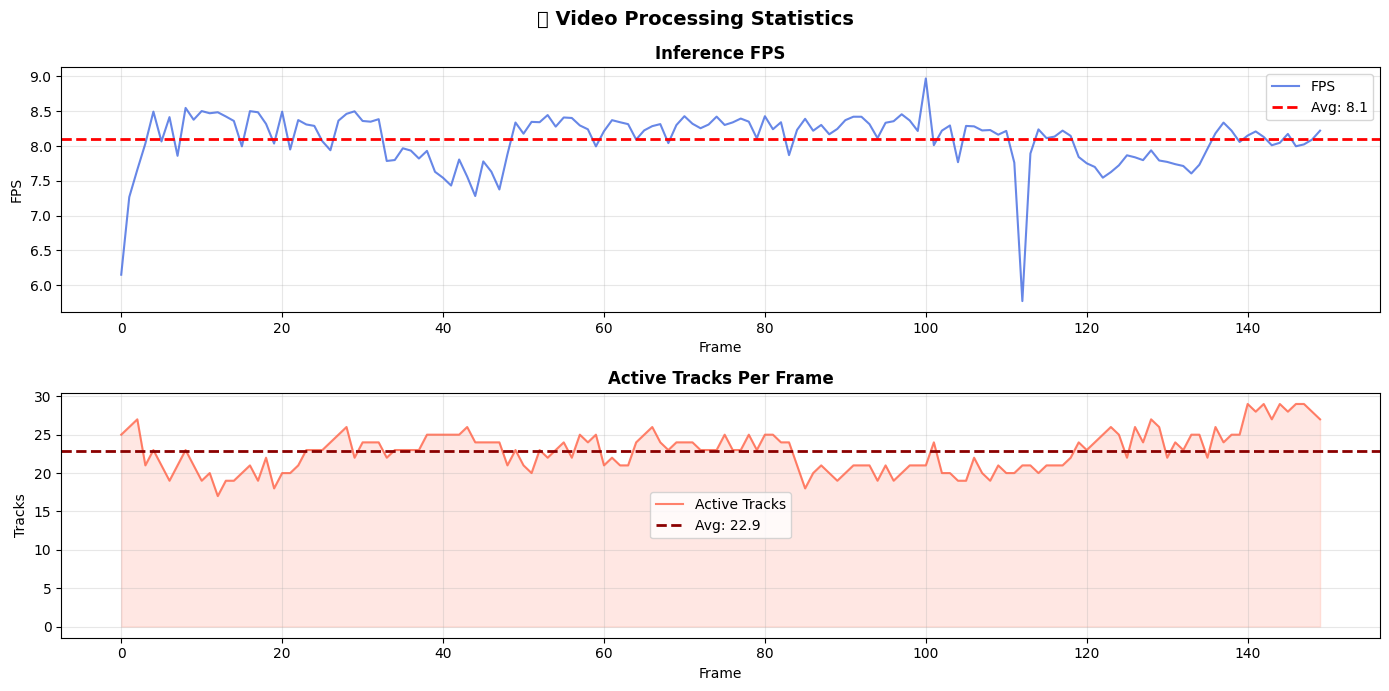


⏳ Downloading Video...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ Download started!

✅ Cell 12 Complete! 🎉


In [24]:
# ============================================
# Cell 12: Complete Self-Contained
#           MOT17 Video Tracker
# ============================================

import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import time
from filterpy.kalman import KalmanFilter
from scipy.optimize import linear_sum_assignment


MOT17_TRAIN    = '/content/MOT17/MOT17/train'
SAVE_PATH      = '/content/checkpoints'
IMG_WIDTH      = 640
IMG_HEIGHT     = 480
CONF_THRESHOLD = 0.5
DEVICE         = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'cpu'
)

print(f"✅ Device : {DEVICE}")
print(f"✅ MOT17  : {MOT17_TRAIN}")
print(f"✅ Save   : {SAVE_PATH}")


# ============================================
# Step 1: Kalman Box Tracker
# ============================================

class KalmanBoxTracker:
    """Single object tracker using Kalman Filter"""

    count = 0

    def __init__(self, bbox):
        self.kf = KalmanFilter(
            dim_x=7, dim_z=4
        )
        self.kf.F = np.array([
            [1,0,0,0,1,0,0],
            [0,1,0,0,0,1,0],
            [0,0,1,0,0,0,1],
            [0,0,0,1,0,0,0],
            [0,0,0,0,1,0,0],
            [0,0,0,0,0,1,0],
            [0,0,0,0,0,0,1]
        ], dtype=float)

        self.kf.H = np.array([
            [1,0,0,0,0,0,0],
            [0,1,0,0,0,0,0],
            [0,0,1,0,0,0,0],
            [0,0,0,1,0,0,0]
        ], dtype=float)

        self.kf.R[2:, 2:] *= 10.0
        self.kf.P[4:, 4:] *= 1000.0
        self.kf.P         *= 10.0
        self.kf.Q[-1,-1]  *= 0.01
        self.kf.Q[4:,4:]  *= 0.01
        self.kf.x[:4]      = self._to_z(bbox)

        self.id                = KalmanBoxTracker.count
        KalmanBoxTracker.count += 1
        self.hits              = 1
        self.hit_streak        = 1
        self.age               = 0
        self.time_since_update = 0
        self.history           = []

    def _to_z(self, bbox):
        return np.array([
            [bbox[0]], [bbox[1]],
            [bbox[2]], [bbox[3]]
        ], dtype=float)

    def _to_bbox(self, x):
        return np.array([
            x[0,0], x[1,0],
            x[2,0], x[3,0]
        ])

    def predict(self):
        self.kf.predict()
        self.age               += 1
        self.time_since_update += 1
        self.history.append(
            self._to_bbox(self.kf.x)
        )
        return self.history[-1]

    def update(self, bbox):
        self.time_since_update = 0
        self.hits             += 1
        self.hit_streak       += 1
        self.history           = []
        self.kf.update(self._to_z(bbox))

    def get_state(self):
        return self._to_bbox(self.kf.x)


# ============================================
# Step 2: IoU Batch Calculator
# ============================================

def iou_batch(bb_test, bb_gt):
    """Compute IoU between all box pairs"""
    bb_gt   = np.expand_dims(bb_gt,   0)
    bb_test = np.expand_dims(bb_test, 1)

    xx1 = np.maximum(bb_test[...,0], bb_gt[...,0])
    yy1 = np.maximum(bb_test[...,1], bb_gt[...,1])
    xx2 = np.minimum(bb_test[...,2], bb_gt[...,2])
    yy2 = np.minimum(bb_test[...,3], bb_gt[...,3])

    w     = np.maximum(0.0, xx2 - xx1)
    h     = np.maximum(0.0, yy2 - yy1)
    inter = w * h

    area_test = (
        (bb_test[...,2] - bb_test[...,0]) *
        (bb_test[...,3] - bb_test[...,1])
    )
    area_gt = (
        (bb_gt[...,2] - bb_gt[...,0]) *
        (bb_gt[...,3] - bb_gt[...,1])
    )

    union = area_test + area_gt - inter + 1e-6
    return inter / union


# ============================================
# Step 3: Hungarian Assignment
# ============================================

def associate_detections(
        detections, trackers,
        iou_threshold=0.3):
    """Match detections to trackers"""

    if len(trackers) == 0:
        return (
            np.empty((0,2), dtype=int),
            np.arange(len(detections)),
            np.empty((0,),  dtype=int)
        )

    iou_matrix = iou_batch(
        detections, trackers
    )

    if min(iou_matrix.shape) > 0:
        row_ind, col_ind = \
            linear_sum_assignment(-iou_matrix)
        matched_indices = np.stack(
            [row_ind, col_ind], axis=1
        )
    else:
        matched_indices = np.empty(
            (0,2), dtype=int
        )

    unmatched_det = []
    for d in range(len(detections)):
        if d not in matched_indices[:,0]:
            unmatched_det.append(d)

    unmatched_trk = []
    for t in range(len(trackers)):
        if t not in matched_indices[:,1]:
            unmatched_trk.append(t)

    matched = []
    for m in matched_indices:
        if iou_matrix[m[0], m[1]] < iou_threshold:
            unmatched_det.append(m[0])
            unmatched_trk.append(m[1])
        else:
            matched.append(m.reshape(1,2))

    if len(matched) == 0:
        matched = np.empty((0,2), dtype=int)
    else:
        matched = np.concatenate(matched, axis=0)

    return (
        matched,
        np.array(unmatched_det),
        np.array(unmatched_trk)
    )


# ============================================
# Step 4: SORT Tracker
# ============================================

class SORTTracker:
    """SORT: Simple Online Realtime Tracking"""

    def __init__(
            self,
            max_age       = 5,
            min_hits      = 3,
            iou_threshold = 0.3):

        self.max_age       = max_age
        self.min_hits      = min_hits
        self.iou_threshold = iou_threshold
        self.trackers      = []
        self.frame_count   = 0
        KalmanBoxTracker.count = 0

    def update(self, detections):
        self.frame_count += 1

        # Predict existing trackers
        trk_preds = []
        to_del    = []

        for i, trk in enumerate(self.trackers):
            pred = trk.predict()
            if np.any(np.isnan(pred)):
                to_del.append(i)
            else:
                trk_preds.append(pred)

        for i in reversed(to_del):
            self.trackers.pop(i)

        trk_arr = np.array(trk_preds) \
            if trk_preds \
            else np.empty((0,4))

        det_arr = detections[:,:4] \
            if len(detections) > 0 \
            else np.empty((0,4))

        matched, unmatched_det, unmatched_trk \
            = associate_detections(
                det_arr, trk_arr,
                self.iou_threshold
            )

        # Update matched
        for m in matched:
            self.trackers[m[1]].update(
                detections[m[0], :4]
            )

        # Create new trackers
        for d in unmatched_det:
            self.trackers.append(
                KalmanBoxTracker(
                    detections[d, :4]
                )
            )

        # Collect results
        results = []
        to_del  = []

        for i, trk in enumerate(self.trackers):
            state = trk.get_state()
            if (
                trk.time_since_update < 1
                and (
                    trk.hit_streak >= self.min_hits
                    or self.frame_count <= self.min_hits
                )
            ):
                results.append(
                    np.concatenate(
                        [state, [trk.id + 1]]
                    )
                )
            if trk.time_since_update > self.max_age:
                to_del.append(i)

        for i in reversed(to_del):
            self.trackers.pop(i)

        return np.array(results) \
            if results \
            else np.empty((0,5))


# ============================================
# Step 5: Draw Tracks on Frame
# ============================================

def draw_tracks(
        frame, tracks,
        fps=None, n_dets=None,
        show_fps=True,
        show_count=True):
    """Draw bounding boxes + IDs on frame"""

    output = frame.copy()

    # Colors per track ID (BGR)
    colors_bgr = [
        (255,107,107), (78,205,196),
        (69,183,209),  (150,206,180),
        (255,234,167), (221,160,221),
        (152,216,200), (247,220,111),
        (187,143,206), (133,193,233),
        (240,178,122), (130,224,170),
        (241,148,138), (133,146,158),
        (115,198,182), (248,196,113),
    ]

    for track in tracks:
        x1,y1,x2,y2 = [
            int(v) for v in track[:4]
        ]
        tid   = int(track[4])
        color = colors_bgr[
            tid % len(colors_bgr)
        ]

        # Bounding box
        cv2.rectangle(
            output,
            (x1, y1), (x2, y2),
            color, thickness=2
        )

        # Label background
        label      = f'ID:{tid}'
        (tw,th), _ = cv2.getTextSize(
            label,
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6, 2
        )
        cv2.rectangle(
            output,
            (x1, max(y1-th-8, 0)),
            (x1+tw+4, y1),
            color, thickness=-1
        )

        # Label text
        cv2.putText(
            output, label,
            (x1+2, max(y1-4, th)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6, (255,255,255),
            thickness=2
        )

    # FPS overlay
    if show_fps and fps is not None:
        cv2.putText(
            output,
            f'FPS: {fps:.1f}',
            (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.9, (0,255,0), thickness=2
        )

    # Track count overlay
    if show_count:
        cv2.putText(
            output,
            f'Tracks: {len(tracks)}',
            (10, 65),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.9, (0,255,255), thickness=2
        )
        if n_dets is not None:
            cv2.putText(
                output,
                f'Dets: {n_dets}',
                (10, 100),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.9, (255,165,0), thickness=2
            )

    return output


# ============================================
# Step 6: Load Saved Model
# ============================================

import torchvision
from torchvision.models.detection import \
    fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn\
    import FastRCNNPredictor

# ============================================
# FIXED: load_model() Function
# ============================================

def load_model(save_path, device):
    """Loads saved Faster R-CNN model"""

    model_path = os.path.join(
        save_path, 'best_model.pth'
    )

    print(f"\n⏳ Loading Model...")
    print(f"   Path: {model_path}")

    if not os.path.exists(model_path):
        print(f"❌ Model not found!")
        return None

    # Build model architecture
    model = fasterrcnn_resnet50_fpn(
        weights=None
    )
    in_features = model.roi_heads \
        .box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = \
        FastRCNNPredictor(in_features, 2)

    # Load checkpoint
    checkpoint = torch.load(
        model_path,
        map_location=device
    )

    # ---- Inspect checkpoint keys ----
    print(f"\n   📋 Checkpoint Keys:")
    for k in checkpoint.keys():
        print(f"      → {k}")

    # ---- Load with correct key ----
    if 'model_state' in checkpoint:
        # ✅ Your checkpoint format
        model.load_state_dict(
            checkpoint['model_state']
        )
        print(f"\n   ✅ Loaded: model_state")
        print(f"   ✅ Epoch : "
              f"{checkpoint.get('epoch', 'N/A')}")
        print(f"   ✅ Val Loss: "
              f"{checkpoint.get('val_loss', 'N/A'):.4f}")

    elif 'model_state_dict' in checkpoint:
        model.load_state_dict(
            checkpoint['model_state_dict']
        )
        print(f"   ✅ Loaded: model_state_dict")

    else:
        # Try loading directly
        try:
            model.load_state_dict(checkpoint)
            print(f"   ✅ Loaded: direct state dict")
        except Exception as e:
            print(f"   ❌ Failed: {e}")
            print(f"\n   Available keys:")
            for k in checkpoint.keys():
                print(f"     → {k}")
            return None

    model.to(device)
    model.eval()
    print(f"\n   ✅ Model ready on {device}!")

    return model



# ============================================
# Step 7: Read Sequence Info
# ============================================

def read_seq_info(seq_path):
    """Read seqinfo.ini for metadata"""
    seq_root  = os.path.dirname(seq_path)
    info_path = os.path.join(
        seq_root, 'seqinfo.ini'
    )
    info = {
        'fps'     : 30,
        'width'   : 1920,
        'height'  : 1080,
        'n_frames': 0
    }
    if os.path.exists(info_path):
        with open(info_path, 'r') as f:
            for line in f:
                line = line.strip()
                if 'frameRate' in line:
                    info['fps'] = int(
                        line.split('=')[1]
                    )
                elif 'imWidth' in line:
                    info['width'] = int(
                        line.split('=')[1]
                    )
                elif 'imHeight' in line:
                    info['height'] = int(
                        line.split('=')[1]
                    )
                elif 'seqLength' in line:
                    info['n_frames'] = int(
                        line.split('=')[1]
                    )
    print(f"\n📹 Sequence Info:")
    print(f"   FPS      : {info['fps']}")
    print(f"   Width    : {info['width']}")
    print(f"   Height   : {info['height']}")
    print(f"   N Frames : {info['n_frames']}")
    return info


# ============================================
# Step 8: Plot Stats
# ============================================

def plot_video_stats(stats):
    """Plot FPS and tracks over time"""

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(14, 7)
    )
    fig.suptitle(
        '📹 Video Processing Statistics',
        fontsize=14, fontweight='bold'
    )

    frames = range(len(stats['fps_history']))

    # FPS
    ax1.plot(
        frames, stats['fps_history'],
        color='royalblue', linewidth=1.5,
        alpha=0.8, label='FPS'
    )
    ax1.axhline(
        np.mean(stats['fps_history']),
        color='red', linestyle='--',
        linewidth=2.0,
        label=f"Avg: "
              f"{np.mean(stats['fps_history']):.1f}"
    )
    ax1.set_title('Inference FPS',
                  fontweight='bold')
    ax1.set_xlabel('Frame')
    ax1.set_ylabel('FPS')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Tracks
    ax2.plot(
        frames, stats['track_history'],
        color='tomato', linewidth=1.5,
        alpha=0.8, label='Active Tracks'
    )
    ax2.fill_between(
        frames, stats['track_history'],
        alpha=0.15, color='tomato'
    )
    ax2.axhline(
        np.mean(stats['track_history']),
        color='darkred', linestyle='--',
        linewidth=2.0,
        label=f"Avg: "
              f"{np.mean(stats['track_history']):.1f}"
    )
    ax2.set_title('Active Tracks Per Frame',
                  fontweight='bold')
    ax2.set_xlabel('Frame')
    ax2.set_ylabel('Tracks')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    path = os.path.join(
        SAVE_PATH, 'video_stats.png'
    )
    plt.savefig(path, dpi=150,
                bbox_inches='tight')
    print(f"  💾 Saved: video_stats.png")
    plt.show()


# ============================================
# Step 9: Main Processing Pipeline
# ============================================

def process_mot17_sequence(
        model, seq_path,
        output_path,
        conf_threshold = 0.5,
        max_frames     = 150,
        max_age        = 5,
        min_hits       = 3,
        iou_threshold  = 0.3):
    """Full detection + tracking pipeline"""

    # Get sorted frames
    frames = sorted([
        f for f in os.listdir(seq_path)
        if f.endswith('.jpg')
        or f.endswith('.png')
    ])

    print(f"\n✅ Found {len(frames)} frames")

    # Limit frames
    if max_frames:
        frames = frames[:max_frames]
    print(f"   Processing: {len(frames)}")

    # Sequence info
    seq_info = read_seq_info(seq_path)

    # Video writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out    = cv2.VideoWriter(
        output_path,
        fourcc,
        seq_info['fps'],
        (seq_info['width'], seq_info['height'])
    )

    # SORT tracker
    tracker = SORTTracker(
        max_age       = max_age,
        min_hits      = min_hits,
        iou_threshold = iou_threshold
    )

    model.eval()

    fps_history   = []
    track_history = []
    total_tracks  = set()

    print(f"\n{'='*55}")
    print(f"🎬 Processing Sequence...")
    print(f"{'='*55}")

    for idx, fname in enumerate(frames):

        t_start = time.time()

        # Read frame
        frame = cv2.imread(
            os.path.join(seq_path, fname)
        )
        if frame is None:
            continue

        orig_h, orig_w = frame.shape[:2]

        # Preprocess
        resized = cv2.resize(
            frame, (IMG_WIDTH, IMG_HEIGHT)
        )
        rgb    = cv2.cvtColor(
            resized, cv2.COLOR_BGR2RGB
        )
        tensor = torch.from_numpy(
            rgb.copy()
        ).float() / 255.0
        tensor = tensor.permute(2, 0, 1)

        # Detect
        with torch.no_grad():
            output = model(
                [tensor.to(DEVICE)]
            )[0]

        # Filter confidence
        keep   = (
            output['scores'] >= conf_threshold
        )
        boxes  = output['boxes'][keep]\
            .cpu().numpy()
        scores = output['scores'][keep]\
            .cpu().numpy()

        # Format detections
        detections = np.column_stack(
            [boxes, scores]
        ) if len(boxes) > 0 \
          else np.empty((0,5))

        # Update tracker
        tracks = tracker.update(detections)

        # Scale to original resolution
        sx = orig_w / IMG_WIDTH
        sy = orig_h / IMG_HEIGHT

        scaled = []
        for t in tracks:
            x1,y1,x2,y2,tid = t
            scaled.append([
                x1*sx, y1*sy,
                x2*sx, y2*sy,
                tid
            ])
        scaled = np.array(scaled) \
            if scaled \
            else np.empty((0,5))

        # FPS
        fps = 1.0 / max(
            time.time() - t_start, 1e-6
        )
        fps_history.append(fps)

        # Draw
        frame_out = draw_tracks(
            frame, scaled,
            fps=fps, n_dets=len(boxes),
            show_fps=True, show_count=True
        )

        out.write(frame_out)

        # Stats
        for t in tracks:
            total_tracks.add(int(t[4]))
        track_history.append(len(tracks))

        # Progress
        if (idx+1) % 30 == 0:
            avg_fps = np.mean(
                fps_history[-30:]
            )
            pct = (idx+1)/len(frames)*100
            print(
                f"  Frame {idx+1:4d}/"
                f"{len(frames)} "
                f"({pct:5.1f}%) | "
                f"FPS: {avg_fps:5.1f} | "
                f"Tracks: {len(tracks):3d}"
            )

    out.release()

    avg_fps    = np.mean(fps_history) \
        if fps_history else 0
    avg_tracks = np.mean(track_history) \
        if track_history else 0

    print(f"\n{'='*55}")
    print(f"✅ Processing Complete!")
    print(f"{'='*55}")
    print(f"  Frames     : {len(frames)}")
    print(f"  Track IDs  : {len(total_tracks)}")
    print(f"  Avg FPS    : {avg_fps:.1f}")
    print(f"  Avg Tracks : {avg_tracks:.1f}")
    print(f"  Output     : {output_path}")

    return {
        'fps_history'  : fps_history,
        'track_history': track_history,
        'total_tracks' : total_tracks,
        'output_path'  : output_path
    }


# ============================================
# Step 10: Run Everything
# ============================================

print("=" * 55)
print("🚀 Cell 12: MOT17 Video Tracker")
print("=" * 55)

# Load model
model = load_model(SAVE_PATH, DEVICE)

if model is None:
    print("\n❌ Model not found!")
    print("   Re-run Cell 8 to retrain")
else:
    # Show available sequences
    print(f"\n📂 Available Sequences:")
    seqs = sorted(os.listdir(MOT17_TRAIN))
    for i, s in enumerate(seqs):
        img = os.path.join(
            MOT17_TRAIN, s, 'img1'
        )
        n = len(os.listdir(img)) \
            if os.path.exists(img) else 0
        print(f"  [{i}] {s} → {n} frames")

    # Pick sequence (change index here!)
    SEQUENCE = seqs[0]
    SEQ_PATH = os.path.join(
        MOT17_TRAIN, SEQUENCE, 'img1'
    )
    OUT_PATH = os.path.join(
        SAVE_PATH,
        f'{SEQUENCE}_tracked.mp4'
    )

    print(f"\n▶️  Using: {SEQUENCE}")

    # Process
    stats = process_mot17_sequence(
        model          = model,
        seq_path       = SEQ_PATH,
        output_path    = OUT_PATH,
        conf_threshold = CONF_THRESHOLD,
        max_frames     = 150,
        max_age        = 5,
        min_hits       = 3,
        iou_threshold  = 0.3
    )

    if stats:
        # Plot stats
        print("\n⏳ Plotting Stats...")
        plot_video_stats(stats)

        # Download
        print("\n⏳ Downloading Video...")
        try:
            from google.colab import files
            files.download(OUT_PATH)
            print("  ✅ Download started!")
        except Exception as e:
            print(f"  📁 Saved at: {OUT_PATH}")

        print(f"\n{'='*55}")
        print(f"✅ Cell 12 Complete! 🎉")
        print(f"{'='*55}")
